# **Aplicación práctica: generación, contaminación y filtrado de una señal ECG sintética**

## **1.Introducción y planteamiento del experimento**

### 1.1 Objetivo del notebook

En este notebook se desarrolla la aplicación práctica del TFG. El objetivo es generar una señal ECG sintética mediante el modelo dinámico de McSharry, añadir perturbaciones representativas y estudiar cómo distintas estrategias de filtrado modifican la señal tanto en el dominio temporal como en el dominio frecuencial.

El interés principal no es diseñar un filtro óptimo, sino analizar el compromiso entre reducción de ruido y preservación morfológica del ECG. En particular, se estudia cómo la longitud del filtro, el tipo de ventana y la frecuencia de corte afectan a rasgos relevantes como el complejo QRS, la amplitud del pico R y el intervalo QT.

La estructura del notebook sigue el mismo orden que la aplicación descrita en el trabajo: generación del ECG limpio, adición de perturbaciones, aplicación de filtros, visualización de sus respuestas y evaluación cuantitativa mediante métricas globales y morfológicas.

### 1.2 Fuentes y criterio de trabajo

La base conceptual del notebook se apoya en tres bloques:

- el modelo dinámico de McSharry para generar una señal ECG sintética con morfología PQRST y variabilidad RR;
- la teoría de señales y sistemas sobre análisis de Fourier, filtros LTI, respuesta impulsional y representación en frecuencia;
- las referencias de procesado biomédico utilizadas para caracterizar la señal ECG y sus perturbaciones principales.

Referencias principales:

[1] McSharry et al., *A Dynamical Model for Generating Synthetic Electrocardiogram Signals*.

[2] MIT HST, apuntes sobre DTFT, DFT y filtrado.

[3] Oppenheim, Willsky & Nawab, *Signals and Systems*.

[4] Rangayyan, *Biomedical Signal Analysis*.


### 1.3 Configuración general del notebook

#### Librerías utilizadas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import find_peaks, peak_widths

En esta celda se importan las librerías necesarias para:

- trabajar con arrays y operaciones matemáticas (`numpy`),
- organizar resultados tabulados (`pandas`),
- representar señales y espectros (`matplotlib`),
- y aplicar funciones de procesado de señal (`scipy.signal`).

Simplemente se prepara el entorno de trabajo.

#### Parámetros globales del experimento
En esta celda se fijan los parámetros generales de la simulación utilizados a lo largo del notebook:

- `fs`: frecuencia de muestreo del ECG sintético.
- `duracion`: duración total de la señal generada.
- `hr_media_bpm`: frecuencia cardíaca media en pulsaciones por minuto.
- `rr_mean`: intervalo RR medio asociado a `hr_media_bpm`.
- `rr_std`: variabilidad introducida en la serie RR.
- `f_lf` y `f_hf`: frecuencias asociadas a las componentes LF y HF de la variabilidad RR.
- `sigma_lf` y `sigma_hf`: amplitudes relativas de dichas componentes.
- `c_lf` y `c_hf`: anchuras espectrales utilizadas en la construcción del tacograma RR.

En el modelo de McSharry, la señal ECG se obtiene como la coordenada $z(t)$ de una trayectoria tridimensional $(x,y,z)$, y la variabilidad del ritmo se introduce mediante una velocidad angular dependiente del tiempo,
 $\omega(t)=\frac{2\pi}{T(t)}$,
donde $T(t)$ representa el intervalo RR instantáneo. Para reproducir esta variabilidad, se genera un tacograma RR con dos componentes principales: una componente LF en torno a $0.10\,\mathrm{Hz}$ y una componente HF en torno a $0.25\,\mathrm{Hz}$.

In [2]:
# Decisiones prácticas de implementación
fs = 500                 # Hz
duracion = 60            # s
t = np.arange(0, duracion, 1/fs)

# Parámetros generales del ritmo
hr_media_bpm = 60
rr_mean = 60 / hr_media_bpm
rr_std = 0.05            # variabilidad moderada

# Parámetros LF/HF del RR tachogram según el marco de McSharry
f_lf = 0.10              # Hz
f_hf = 0.25              # Hz
c_lf = 0.01
c_hf = 0.01
sigma_lf = 0.5
sigma_hf = 1.0

Los valores de los parámetros se han escogido a partir del modelo de McSharry y de criterios habituales de procesado digital de ECG:

- `fs = 500 Hz`: frecuencia de muestreo suficientemente alta para representar la morfología del ECG y estudiar perturbaciones como la interferencia de red a `50 Hz` [2], [4].

- `duracion = 60 s`: registro suficientemente largo para disponer de varios latidos y calcular métricas medias de forma estable.

- `hr_media_bpm = 60`: frecuencia cardíaca media normal y sencilla de interpretar. Con este valor, el intervalo RR medio es aproximadamente de un segundo.

- `rr_std = 0.05`: introduce una variabilidad moderada en los intervalos RR, evitando una señal perfectamente periódica. El modelo de McSharry permite controlar la media y la variabilidad del ritmo cardíaco [1].

- `f_lf = 0.10 Hz` y `f_hf = 0.25 Hz`: valores basados en el modelo de McSharry, donde la variabilidad RR se representa mediante componentes LF y HF. La componente LF se sitúa alrededor de `0.10 Hz` y la HF alrededor de `0.25 Hz`, asociada a la influencia respiratoria [1].

- `c_lf` y `c_hf`: controlan la anchura espectral de las componentes LF y HF del tacograma RR. Se usan para que los picos espectrales queden localizados alrededor de `f_lf` y `f_hf` [1].

- `sigma_lf` y `sigma_hf`: regulan el peso relativo de las componentes LF y HF, siguiendo la construcción espectral del tacograma RR propuesta por McSharry [1].

#### Funciones auxiliares de visualización y evaluación

Antes de construir el modelo conviene definir funciones auxiliares para representar y evaluar las señales:

- la señal en el dominio temporal,
- su espectro en frecuencia,
- la respuesta en frecuencia de los filtros,
- y el error global mediante el RMSE.

Estas funciones no introducen teoría nueva, pero son necesarias para que el resto del notebook quede mucho más limpio y legible.

In [3]:
def plot_signal(t, x, title="", xlim=None, xlabel="Tiempo [s]", ylabel="Amplitud [mV]"):
    plt.figure(figsize=(12, 4))
    plt.plot(t, x)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if xlim is not None:
        plt.xlim(*xlim)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_spectrum(x, fs, title="", fmax=80):
    X = np.fft.rfft(x - np.mean(x))
    f = np.fft.rfftfreq(len(x), d=1/fs)
    mag = np.abs(X) / len(x)

    plt.figure(figsize=(12, 4))
    plt.plot(f, mag)
    plt.title(title)
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.xlim(0, fmax)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_filter_response(h, fs, title="Respuesta en frecuencia"):
    w, H = signal.freqz(h, worN=4096, fs=fs)
    plt.figure(figsize=(12, 4))
    plt.plot(w, np.abs(H))
    plt.title(title)
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("|H(f)|")
    plt.xlim(0, 80)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def rmse(x, y):
    return np.sqrt(np.mean((x - y)**2))

## **2.Generación de la señal ECG sintética de referencia**

### 2.1 Modelo de McSharry

El modelo de McSharry describe el ECG como la coordenada $z(t)$ de una trayectoria en un sistema dinámico tridimensional. La dinámica en el plano $(x,y)$ fuerza la trayectoria a girar alrededor de un ciclo límite unitario, y la morfología del ECG se genera mediante eventos localizados en posiciones angulares asociadas a las ondas P, Q, R, S y T [1][2].

Además, el modelo separa de forma conceptual:
- la **morfología media** del latido, controlada por los parámetros $a_i$, $b_i$ y $\theta_i$,
- y la **dinámica del ritmo**, controlada por la velocidad angular $\omega(t)$ [1][2].

La variabilidad del intervalo RR se introduce construyendo primero un *RR tachogram* con espectro bimodal LF/HF y definiendo después $\omega(t)=\frac{2\pi}{T(t)}$ [1][2].

In [4]:
def wrap_to_pi(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi


def parametros_mcsharry():
    # Tiempos relativos respecto al pico R, inspirados en la tabla del artículo
    ti = np.array([-0.2, -0.05, 0.0, 0.05, 0.3])
    theta_i = 2 * np.pi * ti

    # Amplitudes y anchuras medias de P, Q, R, S y T
    a_i = np.array([1.2, -5.0, 30.0, -7.5, 0.75])
    b_i = np.array([0.25, 0.10, 0.10, 0.10, 0.40])

    return theta_i, a_i, b_i


def generar_rr_bimodal(duracion, fs_rr=4, rr_mean=1.0, rr_std=0.05,
                       f_lf=0.10, f_hf=0.25, c_lf=0.01, c_hf=0.01,
                       sigma_lf=0.5, sigma_hf=1.0, seed=42):
    """
    Serie RR con espectro bimodal LF/HF, siguiendo la idea de McSharry.
    """
    rng = np.random.default_rng(seed)
    N = int(duracion * fs_rr)
    f = np.fft.rfftfreq(N, d=1/fs_rr)

    S = (
        (sigma_lf**2 / np.sqrt(2*np.pi*c_lf**2)) * np.exp(-((f - f_lf)**2) / (2*c_lf**2))
        +
        (sigma_hf**2 / np.sqrt(2*np.pi*c_hf**2)) * np.exp(-((f - f_hf)**2) / (2*c_hf**2))
    )

    fases = rng.uniform(0, 2*np.pi, len(f))
    X = np.sqrt(S) * np.exp(1j * fases)
    rr0 = np.fft.irfft(X, n=N)

    rr0 = rr0 - np.mean(rr0)
    rr0 = rr0 / np.std(rr0)
    rr = rr_mean + rr_std * rr0
    rr = np.clip(rr, 0.5, 1.5)

    t_rr = np.arange(N) / fs_rr
    return t_rr, rr, f, S


def modelo_mcsharry_variable(estado, tiempo, omega_actual, theta_i, a_i, b_i, A=0.0, f_resp=0.25):
    x, y, z = estado

    alpha = 1 - np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    z0 = A * np.sin(2 * np.pi * f_resp * tiempo)
    delta_theta = wrap_to_pi(theta - theta_i)

    dx = alpha * x - omega_actual * y
    dy = alpha * y + omega_actual * x
    dz = -np.sum(a_i * delta_theta * np.exp(-(delta_theta**2) / (2 * b_i**2))) - (z - z0)

    return np.array([dx, dy, dz])


def rk4_variable(funcion, estado_inicial, t, omega_t, theta_i, a_i, b_i, A=0.0, f_resp=0.25):
    n = len(t)
    dt = t[1] - t[0]
    estados = np.zeros((n, len(estado_inicial)))
    estados[0] = estado_inicial

    for k in range(n - 1):
        tk = t[k]
        yk = estados[k]

        omega1 = omega_t[k]
        omega2 = 0.5 * (omega_t[k] + omega_t[k+1])
        omega3 = omega2
        omega4 = omega_t[k+1]

        k1 = funcion(yk, tk, omega1, theta_i, a_i, b_i, A, f_resp)
        k2 = funcion(yk + 0.5 * dt * k1, tk + 0.5 * dt, omega2, theta_i, a_i, b_i, A, f_resp)
        k3 = funcion(yk + 0.5 * dt * k2, tk + 0.5 * dt, omega3, theta_i, a_i, b_i, A, f_resp)
        k4 = funcion(yk + dt * k3, tk + dt, omega4, theta_i, a_i, b_i, A, f_resp)

        estados[k + 1] = yk + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

    return estados

En este bloque se implementan las funciones necesarias para generar la señal ECG sintética según el modelo de McSharry.

Primero, `wrap_to_pi` se utiliza para expresar las diferencias angulares en el intervalo $[-\pi,\pi]$, evitando discontinuidades debidas a la naturaleza circular del ángulo. Después, `parametros_mcsharry` define los parámetros medios que fijan la posición, amplitud y anchura de las ondas P, Q, R, S y T.

A continuación, `generar_rr_bimodal` construye una serie RR sintética con estructura espectral LF/HF, lo que permite introducir una variabilidad del ritmo cardíaco fisiológicamente razonable. La función `modelo_mcsharry_variable` define el sistema dinámico diferencial del modelo, mientras que `rk4_variable` lo integra numéricamente mediante el método de Runge-Kutta de cuarto orden para obtener la evolución temporal completa de la trayectoria $(x,y,z)$.

### 2.2 Generación del ECG limpio de referencia

En esta celda se ejecuta todo el bloque anterior para generar la señal ECG sintética de referencia.

Primero se construye la serie RR con la estructura bimodal LF/HF definida previamente. A continuación, esa serie se interpola sobre la rejilla temporal fina del ECG para obtener una velocidad angular variable $\omega(t)$. Con esa información, se integra numéricamente el sistema dinámico y se obtiene la trayectoria $(x,y,z)$. Finalmente, se toma la componente $z(t)$ como señal ECG sintética. Esta será la señal de referencia que se utilizará más adelante para comparar el efecto del ruido y del filtrado.

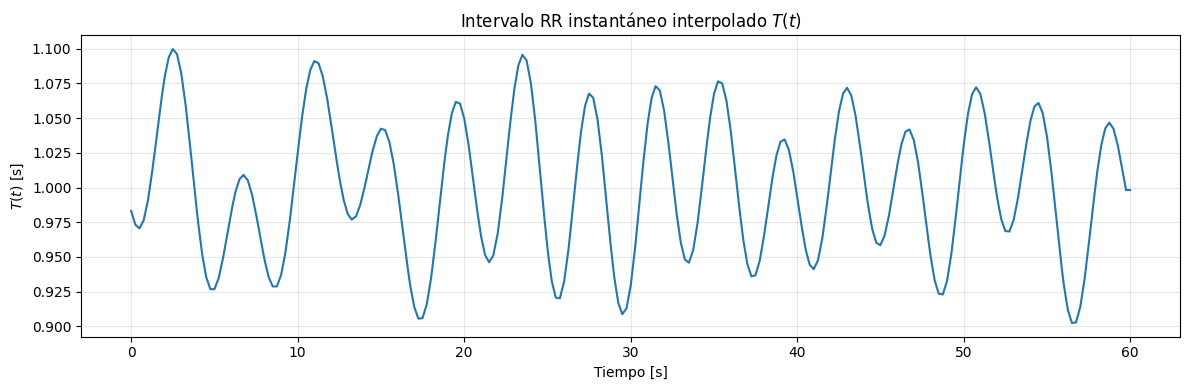

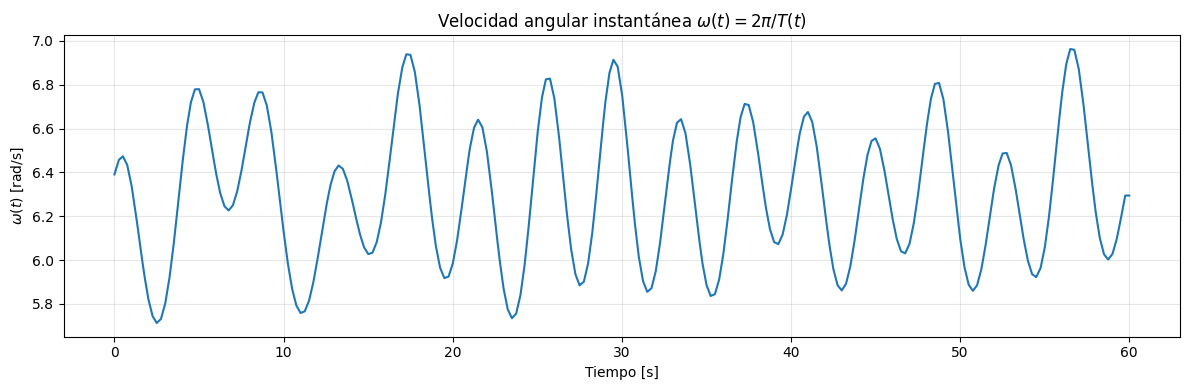

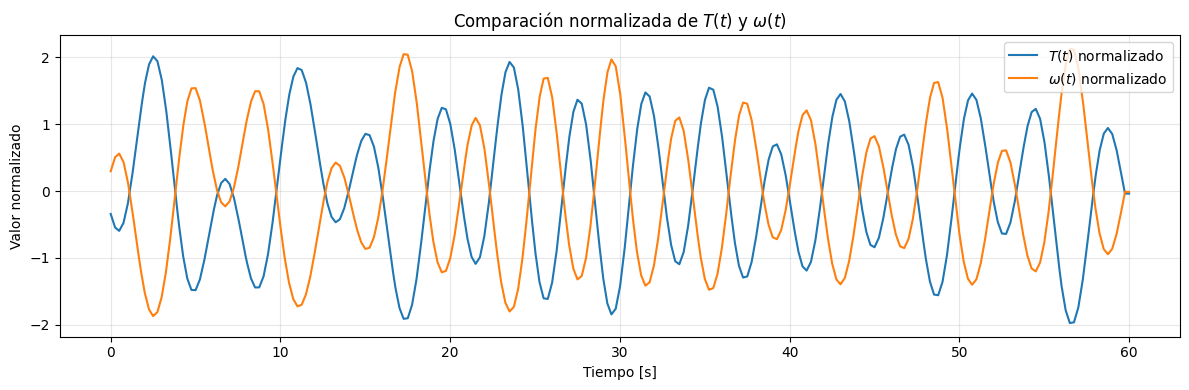

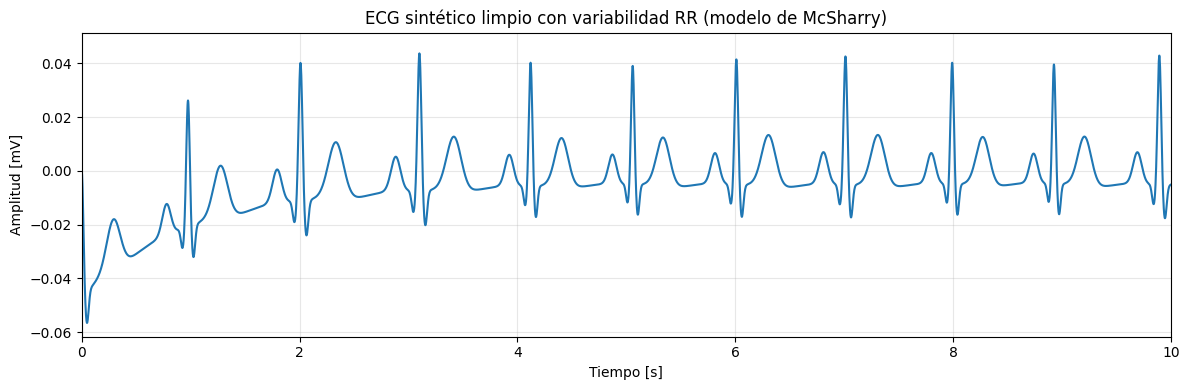

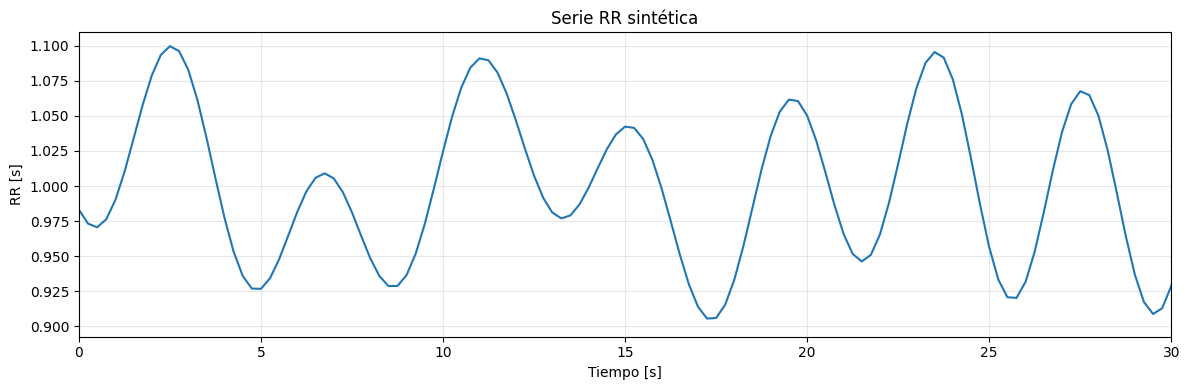

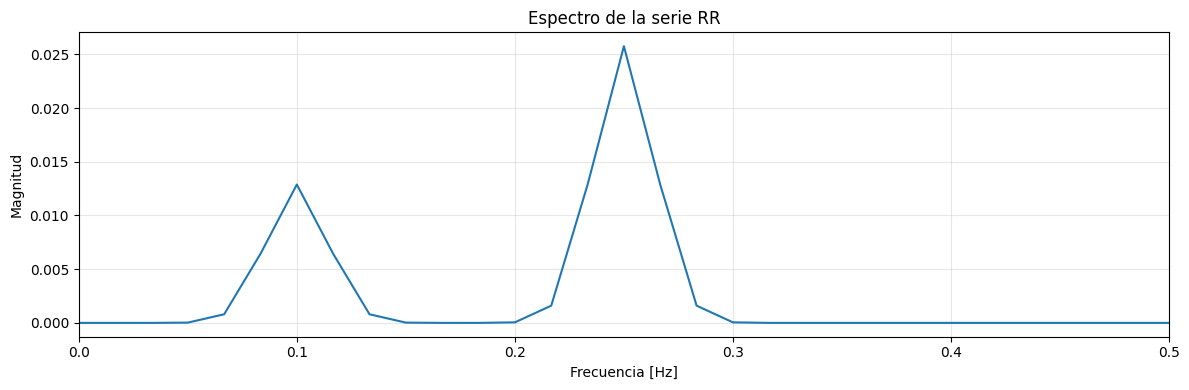

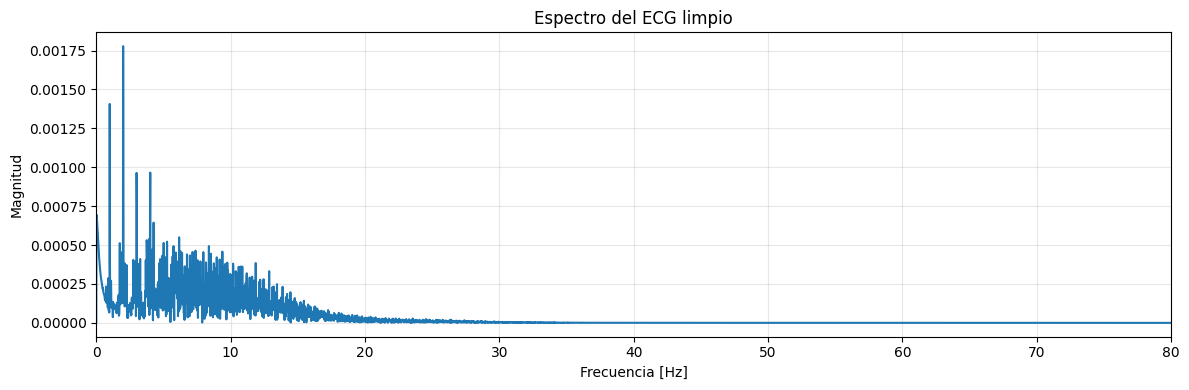

In [5]:
# Parámetros morfológicos
theta_i, a_i, b_i = parametros_mcsharry()

# RR variable
t_rr, rr, f_rr_teorico, S_rr_teorico = generar_rr_bimodal(
    duracion=duracion,
    rr_mean=rr_mean,
    rr_std=rr_std,
    f_lf=f_lf,
    f_hf=f_hf,
    c_lf=c_lf,
    c_hf=c_hf,
    sigma_lf=sigma_lf,
    sigma_hf=sigma_hf,
    seed=42
)

# Interpolación a la rejilla temporal fina del ECG
rr_t = np.interp(t, t_rr, rr)
omega_t = 2 * np.pi / rr_t


# Visualización del intervalo RR instantáneo y de la velocidad angular

plt.figure(figsize=(12, 4))
plt.plot(t, rr_t)
plt.xlabel("Tiempo [s]")
plt.ylabel(r"$T(t)$ [s]")
plt.title(r"Intervalo RR instantáneo interpolado $T(t)$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(t, omega_t)
plt.xlabel("Tiempo [s]")
plt.ylabel(r"$\omega(t)$ [rad/s]")
plt.title(r"Velocidad angular instantánea $\omega(t)=2\pi/T(t)$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Normalización tipo z-score
rr_norm = (rr_t - np.mean(rr_t)) / np.std(rr_t)
omega_norm = (omega_t - np.mean(omega_t)) / np.std(omega_t)

plt.figure(figsize=(12, 4))
plt.plot(t, rr_norm, label=r"$T(t)$ normalizado")
plt.plot(t, omega_norm, label=r"$\omega(t)$ normalizado")

plt.xlabel("Tiempo [s]")
plt.ylabel("Valor normalizado")
plt.title(r"Comparación normalizada de $T(t)$ y $\omega(t)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Simulación del ECG limpio
estado_inicial = np.array([1.0, 0.0, 0.0])
estados = rk4_variable(
    modelo_mcsharry_variable,
    estado_inicial,
    t,
    omega_t,
    theta_i,
    a_i,
    b_i,
    A=0.0,
    f_resp=f_hf
)

ecg_referencia = estados[:, 2]

# Visualizaciones básicas
plot_signal(t, ecg_referencia, "ECG sintético limpio con variabilidad RR (modelo de McSharry)", xlim=(0, 10))
plot_signal(t_rr, rr, "Serie RR sintética", xlim=(0, 30), ylabel="RR [s]")
plot_spectrum(rr, fs=4, title="Espectro de la serie RR", fmax=0.5)
plot_spectrum(ecg_referencia, fs, title="Espectro del ECG limpio", fmax=80)

En este bloque se obtienen las variables principales del experimento. Primero se calculan los parámetros morfológicos del modelo de McSharry y se genera una serie RR sintética con la variabilidad definida previamente. Después, esta serie RR se interpola sobre la malla temporal fina del ECG para obtener el intervalo RR instantáneo $T(t)$ en cada muestra.

A partir de $T(t)$, se calcula la velocidad angular instantánea


$\omega(t)=\frac{2\pi}{T(t)}$

Las dos primeras gráficas muestran precisamente $T(t)$ y $\omega(t)$. Como ambas magnitudes son inversamente proporcionales, cuando $T(t)$ aumenta la velocidad angular disminuye, y cuando $T(t)$ disminuye la velocidad angular aumenta. La tercera gráfica muestra ambas variables normalizadas, lo que permite visualizar mejor esta relación inversa.

Esta variabilidad hace que la fase del ciclo cardíaco no avance siempre a la misma velocidad. Por tanto, la trayectoria no completa todas las vueltas en el mismo tiempo y la señal ECG sintética no es estrictamente periódica. Esto permite simular cambios latido a latido en el ritmo cardíaco.

Finalmente, se integra numéricamente el sistema dinámico de McSharry mediante RK4 con una condición inicial fija. La trayectoria obtenida es $(x(t),y(t),z(t))$, y la componente $z(t)$ se toma como señal ECG limpia de referencia. Al final del bloque se representan la señal ECG generada, la serie RR y sus espectros, para comprobar visualmente que la simulación es coherente antes de añadir ruido y aplicar los filtros.

## **3.Construcción de la señal contaminada y estrategia de filtrado**

#### 3.1 Adición de ruido y artefactos

El ECG real puede contaminarse con distintas perturbaciones. En este notebook se consideran tres contaminantes representativos:

- una deriva lenta de línea de base;
- una interferencia sinusoidal a $50\,\mathrm{Hz}$;
- y ruido blanco gaussiano.

El objetivo no es reproducir todos los artefactos clínicos posibles, sino construir una señal contaminada controlada sobre la que estudiar el efecto del filtrado. Cada perturbación se ha elegido porque afecta a una región frecuencial distinta: baja frecuencia, una frecuencia localizada y banda ancha.

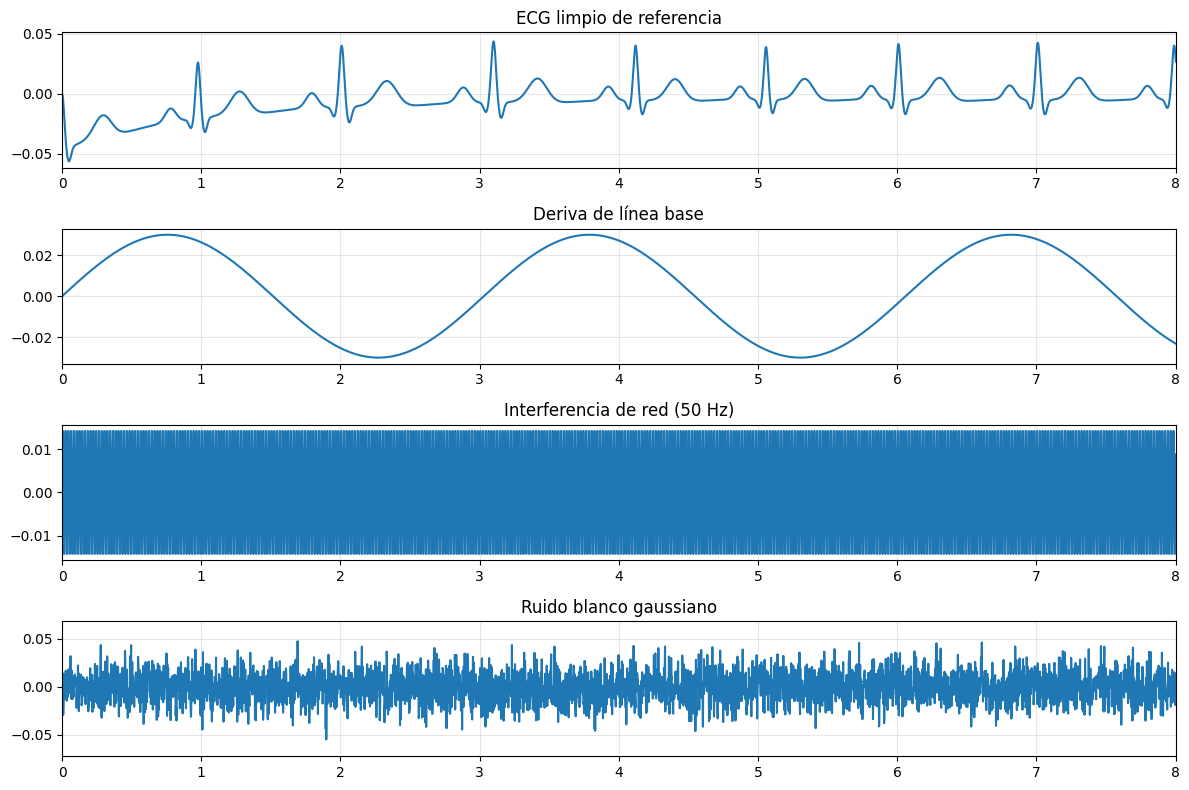

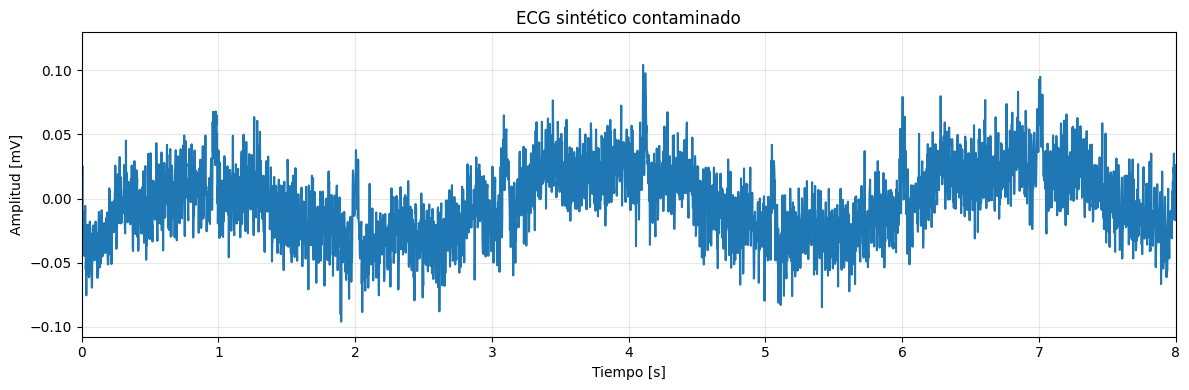

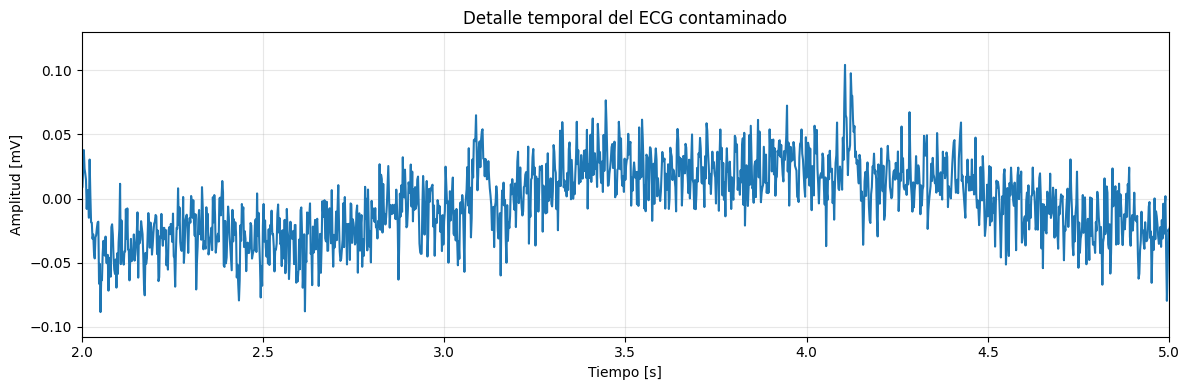

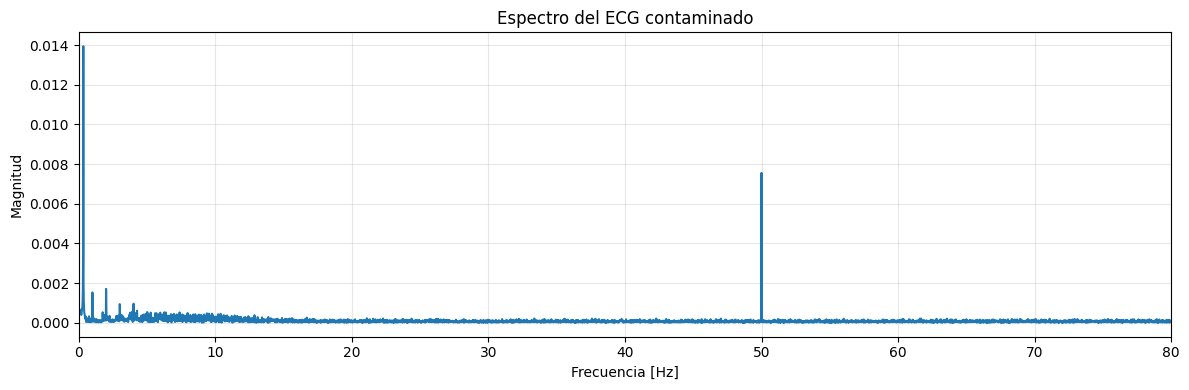

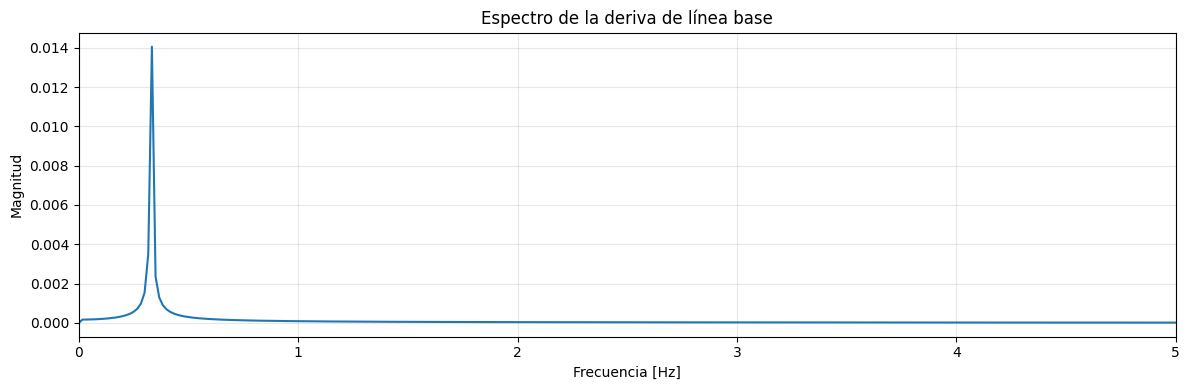

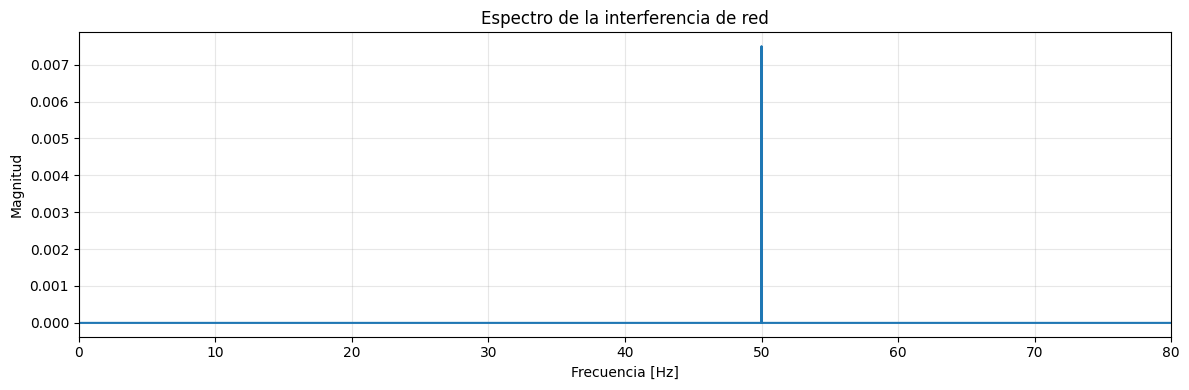

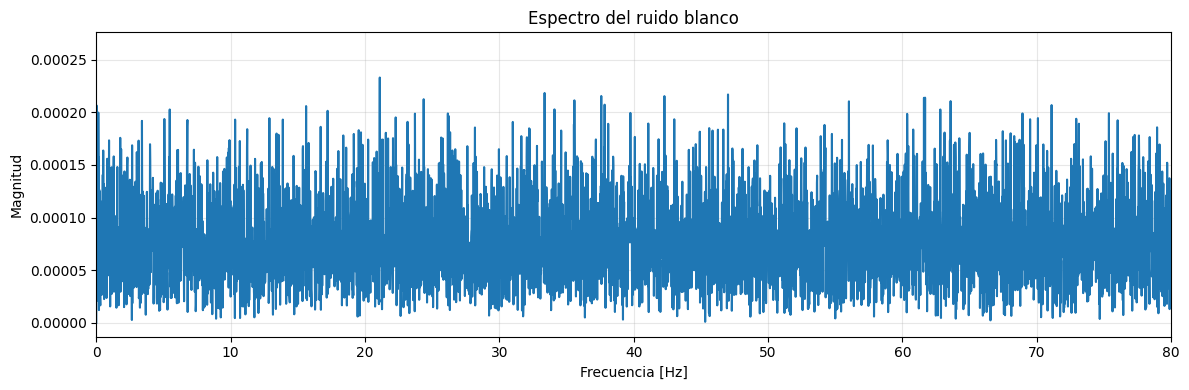

In [6]:
# Parámetros de las perturbaciones añadidas al ECG
amp_baseline = 0.03
f_baseline = 0.33

amp_red = 0.015
f_red = 50

sigma_blanco = 0.015
rng = np.random.default_rng(42)

# Componentes de ruido
ruido_baseline = amp_baseline * np.sin(2 * np.pi * f_baseline * t)
ruido_red = amp_red * np.sin(2 * np.pi * f_red * t)
ruido_blanco = rng.normal(0, sigma_blanco, len(t))

# Señal contaminada
ecg_ruidoso = ecg_referencia + ruido_baseline + ruido_red + ruido_blanco

# Visualización
plt.figure(figsize=(12,8))

plt.subplot(4,1,1)
plt.plot(t, ecg_referencia)
plt.title("ECG limpio de referencia")
plt.xlim(0, 8)
plt.grid(True, alpha=0.3)

plt.subplot(4,1,2)
plt.plot(t, ruido_baseline)
plt.title("Deriva de línea base")
plt.xlim(0, 8)
plt.grid(True, alpha=0.3)

plt.subplot(4,1,3)
plt.plot(t, ruido_red)
plt.title("Interferencia de red (50 Hz)")
plt.xlim(0, 8)
plt.grid(True, alpha=0.3)

plt.subplot(4,1,4)
plt.plot(t, ruido_blanco)
plt.title("Ruido blanco gaussiano")
plt.xlim(0, 8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plot_signal(t, ecg_ruidoso, "ECG sintético contaminado", xlim=(0, 8))
plot_signal(t, ecg_ruidoso, "Detalle temporal del ECG contaminado", xlim=(2, 5))
plot_spectrum(ecg_ruidoso, fs, "Espectro del ECG contaminado", fmax=80)
plot_spectrum(ruido_baseline, fs, "Espectro de la deriva de línea base", fmax=5)
plot_spectrum(ruido_red, fs, "Espectro de la interferencia de red", fmax=80)
plot_spectrum(ruido_blanco, fs, "Espectro del ruido blanco", fmax=80)

Las representaciones temporales permiten comprobar que cada perturbación añadida tiene un comportamiento distinto. La deriva de línea base introduce una oscilación lenta que desplaza suavemente la señal hacia arriba y hacia abajo; la interferencia de red añade una componente periódica rápida a 50 Hz; y el ruido blanco gaussiano produce fluctuaciones aleatorias distribuidas a lo largo de toda la señal. Como resultado, el ECG contaminado presenta simultáneamente una distorsión de baja frecuencia, una oscilación estrecha en torno a 50 Hz y una componente de ruido de banda ancha.

En el dominio frecuencial, estas diferencias se observan de forma más clara. La deriva de línea base concentra su energía en frecuencias muy bajas, la interferencia de red aparece como un pico localizado en 50 Hz y el ruido blanco muestra una distribución espectral más extendida. Esta construcción controlada permite disponer de una señal contaminada con artefactos bien identificables, adecuada para analizar después cómo actúan los distintos filtros sobre cada tipo de perturbación.

Los parámetros utilizados para construir estas perturbaciones se han elegido de forma coherente con los rangos frecuenciales típicos descritos en la bibliografía biomédica. En particular, la deriva de línea base se modela mediante una oscilación lenta de aproximadamente $0.33\,\mathrm{Hz}$, valor situado dentro del rango habitual de bajas frecuencias asociado a respiración y movimiento lento. La interferencia de red se fija en $50\,\mathrm{Hz}$, coincidiendo con la frecuencia de la red eléctrica europea. Por último, el ruido blanco gaussiano se utiliza como una aproximación sencilla a perturbaciones de banda ancha distribuidas sobre gran parte del espectro.

Las amplitudes escogidas no pretenden reproducir exactamente un registro clínico concreto, sino generar una señal contaminada donde cada perturbación sea claramente visible y permita analizar de forma controlada el efecto de los filtros sobre distintas regiones frecuenciales del ECG.

#### 3.2 Diseño del filtrado

En el texto teórico del TFG se denota por $F_{\mathrm{pb}}$ la frecuencia de corte del filtro paso bajo. En el código, por comodidad, esta misma magnitud aparece como `fc_lp_hz` o como `fc` en los experimentos donde se prueban varios valores. Por tanto,

$
F_{\mathrm{pb}} \equiv \texttt{fc_lp_hz}
$

cuando se utiliza un único filtro paso bajo, y

$
F_{\mathrm{pb}} \equiv \texttt{fc}
$

cuando se recorre una lista de frecuencias de corte en el experimento 3.

#### 3.3 Filtrado del ECG contaminado

En este trabajo, la parte central del análisis consiste en estudiar cómo distintas aproximaciones de filtrado paso bajo afectan a la morfología temporal del ECG. Para ello, en el notebook se sigue un esquema en dos etapas:

1. **Preprocesado básico de perturbaciones identificables**
   - filtro *high-pass* para reducir la deriva de línea base;
   - filtro *notch* para atenuar la interferencia de red a $50\,\mathrm{Hz}$.

2. **Comparación principal del TFG**
   - filtro paso bajo ideal definido en frecuencia, utilizado como referencia teórica;
   - filtro FIR rectangular corto;
   - filtro FIR rectangular largo;
   - filtro FIR con ventana de Hamming.

El filtro ideal se incluye únicamente como referencia conceptual para estudiar el efecto de un corte frecuencial abrupto. Sin embargo, al estar definido directamente mediante una máscara frecuencial de corte brusco, no se interpreta como una implementación FIR práctica de longitud finita.

La comparación principal se centra en los filtros FIR, ya que permiten estudiar cómo la longitud del filtro y el tipo de ventana modifican simultáneamente la respuesta frecuencial y la morfología temporal del ECG.

In [7]:
# Filtro ideal por FFT:
# Se incluye como referencia teórica de corte abrupto.
# No se considera una implementación FIR práctica de longitud finita.
def filtro_ideal_fft(x, fs, fc_hz):
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(len(x), d=1/fs)
    H = np.where(f <= fc_hz, 1.0, 0.0)
    y = np.fft.irfft(X * H, n=len(x))
    return y, f, H


def respuesta_impulsional_ideal_paso_bajo(fc_norm, M):
    n = np.arange(M)
    alpha = (M - 1) / 2
    m = n - alpha
    h = 2 * fc_norm * np.sinc(2 * fc_norm * m)
    return h

# Se usa filtfilt para evitar desfases temporales artificiales en los picos del ECG.
def aplicar_filtro_fir_cero_fase(x, h):
    return signal.filtfilt(h, [1.0], x)


# ---- PREPROCESADO ----
# Decisiones prácticas de implementación
fc_hp = 0.5
orden_hp = 4

b_hp, a_hp = signal.butter(orden_hp, fc_hp, btype='highpass', fs=fs)
ecg_hp = signal.filtfilt(b_hp, a_hp, ecg_ruidoso)

f0 = 50
Q = 30
b_notch, a_notch = signal.iirnotch(f0, Q, fs)
ecg_preprocesado = signal.filtfilt(b_notch, a_notch, ecg_hp)

# ---- PASO BAJO: ideal + realizables ----
fc_lp_hz = 25
fc_lp_norm = fc_lp_hz / fs

ecg_ideal, f_ideal, H_ideal = filtro_ideal_fft(ecg_preprocesado, fs, fc_lp_hz)

M_corto = 41
M_largo = 201

h_rect_corto = respuesta_impulsional_ideal_paso_bajo(fc_lp_norm, M_corto)
h_rect_corto = h_rect_corto / np.sum(h_rect_corto)

h_rect_largo = respuesta_impulsional_ideal_paso_bajo(fc_lp_norm, M_largo)
h_rect_largo = h_rect_largo / np.sum(h_rect_largo)

ecg_rect_corto = aplicar_filtro_fir_cero_fase(ecg_preprocesado, h_rect_corto)
ecg_rect_largo = aplicar_filtro_fir_cero_fase(ecg_preprocesado, h_rect_largo)

h_hamming = respuesta_impulsional_ideal_paso_bajo(fc_lp_norm, M_largo)
h_hamming = h_hamming * np.hamming(M_largo)
h_hamming = h_hamming / np.sum(h_hamming)

ecg_hamming = aplicar_filtro_fir_cero_fase(ecg_preprocesado, h_hamming)

# Señales a comparar
senales_a_comparar = {
    "Ruidoso": ecg_ruidoso,
    "Preprocesado": ecg_preprocesado,
    "Ideal": ecg_ideal,
    "Rectangular corto": ecg_rect_corto,
    "Rectangular largo": ecg_rect_largo,
    "Hamming": ecg_hamming
}

filtros_practicos = ["Rectangular corto", "Rectangular largo", "Hamming"]
referencias_teoricas = ["Ideal"]
casos_no_finales = ["Ruidoso", "Preprocesado"]

En este bloque se construyen todas las señales que se compararán en el análisis final. Primero se aplica un preprocesado básico sobre el ECG contaminado: un filtro *high-pass* para reducir la deriva de línea base y un filtro *notch* para atenuar la interferencia de red a $50\,\mathrm{Hz}$. El resultado de esta etapa es una señal preprocesada en la que se han reducido los contaminantes más fácilmente identificables antes de aplicar el filtrado paso bajo principal.

A continuación, sobre esa señal preprocesada se aplica el filtrado paso bajo que constituye el núcleo del experimento. Se obtiene, por un lado, una referencia ideal en frecuencia y, por otro, tres filtros FIR: dos filtros rectangulares de distinta longitud y un filtro con ventana de Hamming. Estas señales permiten comparar distintos compromisos entre selectividad frecuencial, extensión temporal del filtro y preservación morfológica del ECG.

## **4.Comparación principal entre filtros**

### 4.1 Comparación visual en tiempo y frecuencia

#### Visualización del comportamiento de los filtros

Las siguientes gráficas permiten comparar los filtros desde tres puntos de vista:

1. la respuesta temporal del filtro;
2. la respuesta en frecuencia;
3. el efecto del filtrado sobre un fragmento del ECG.

Esta comparación es importante porque dos filtros pueden tener un comportamiento parecido en frecuencia, pero producir pequeñas diferencias en el dominio temporal, especialmente alrededor de zonas rápidas como el complejo QRS.

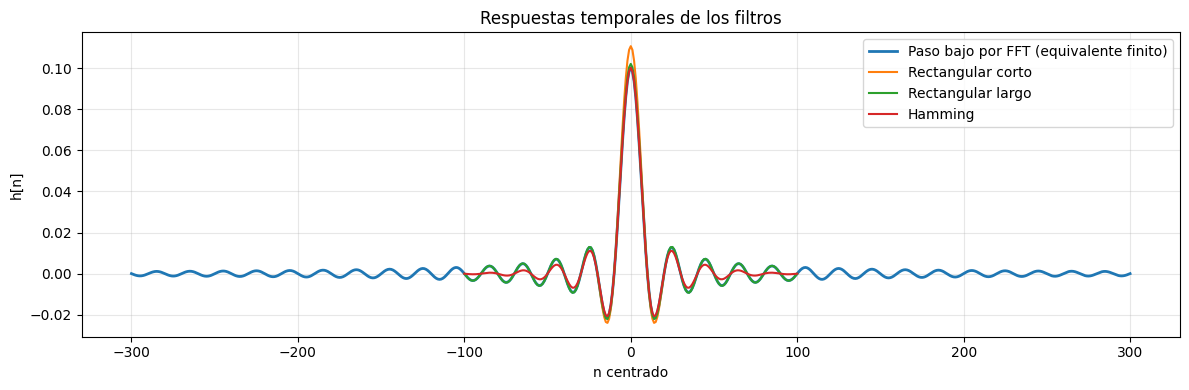

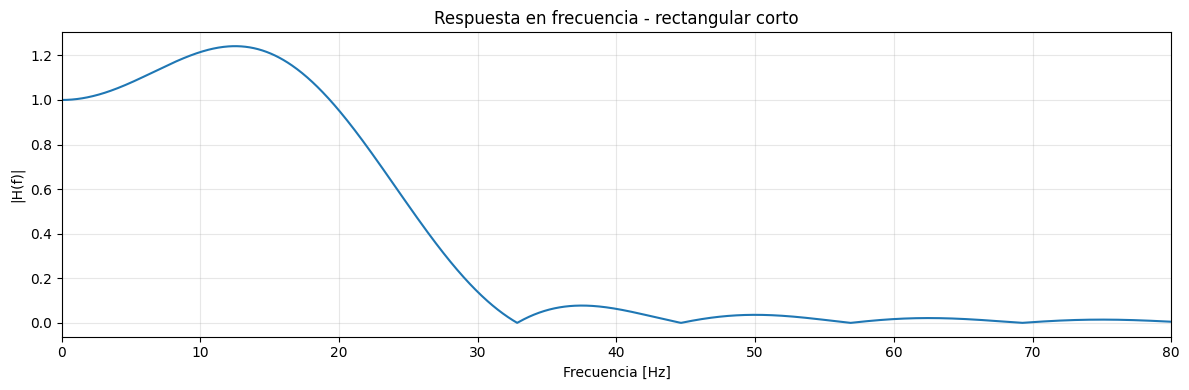

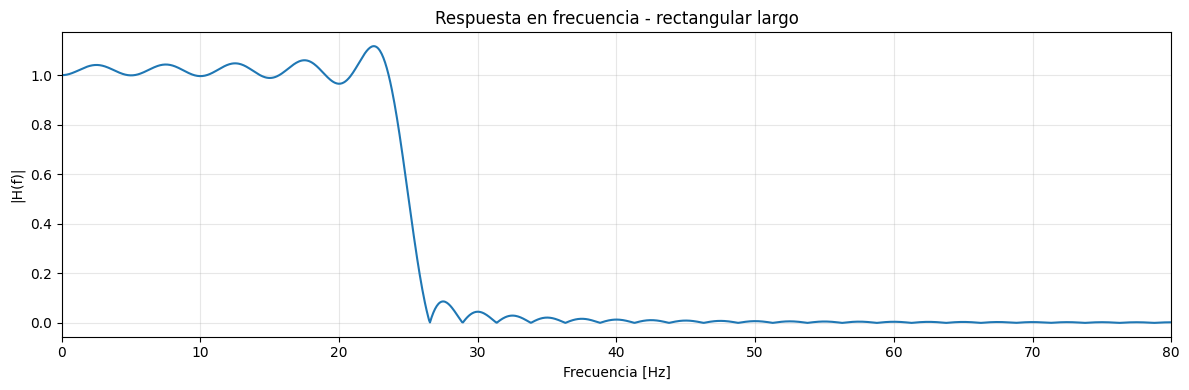

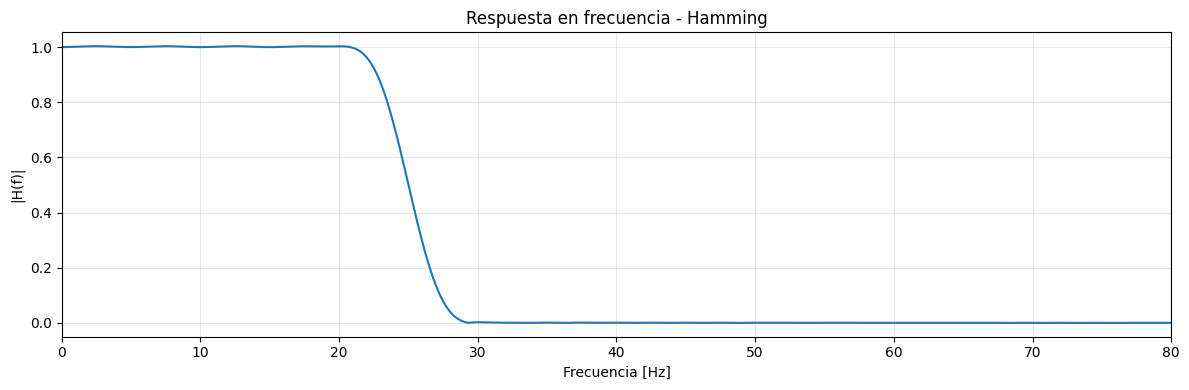

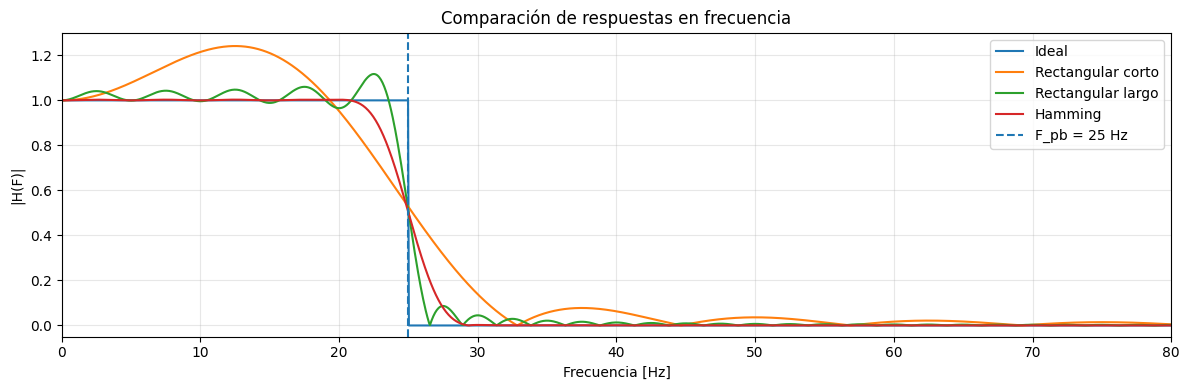

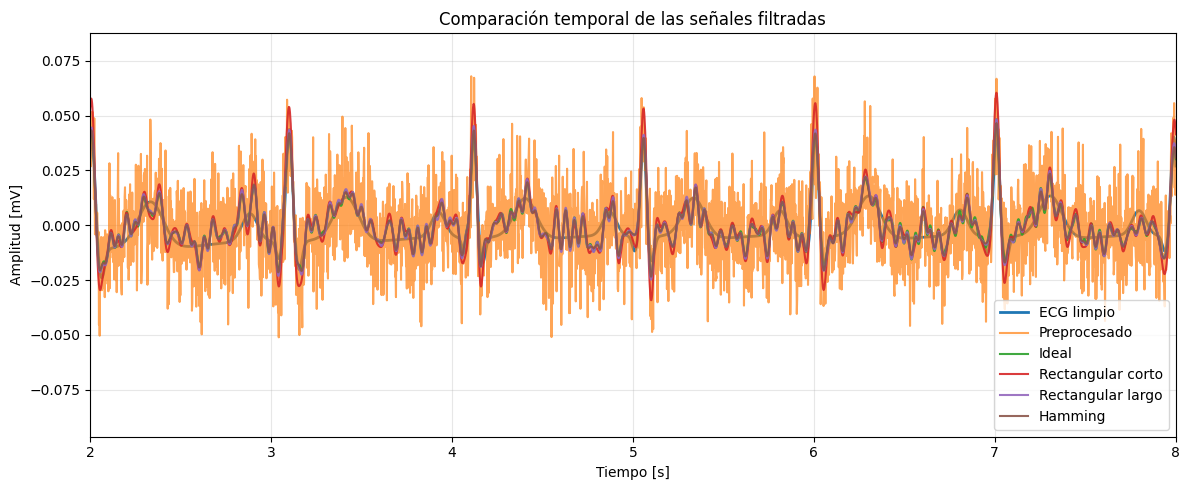

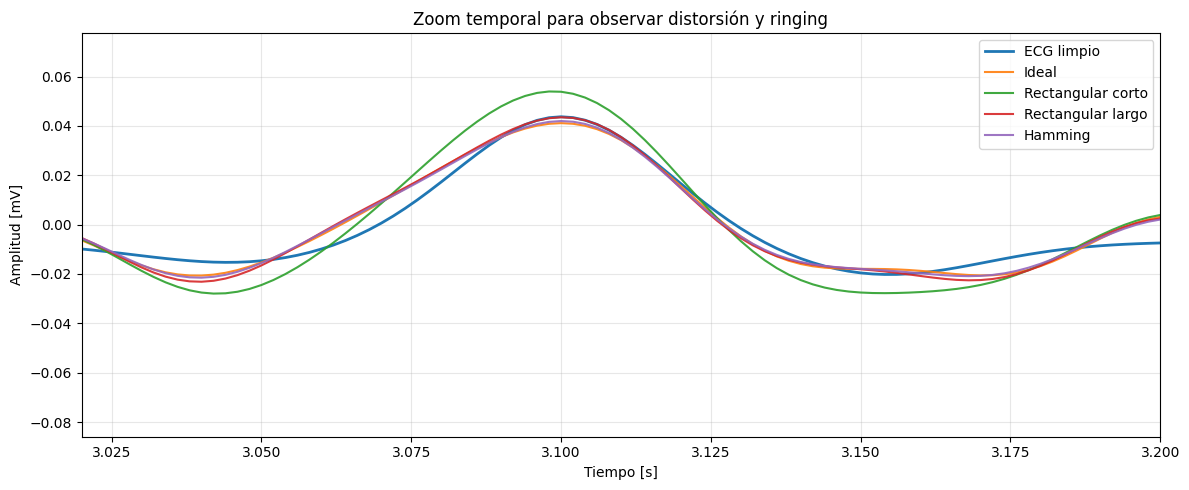

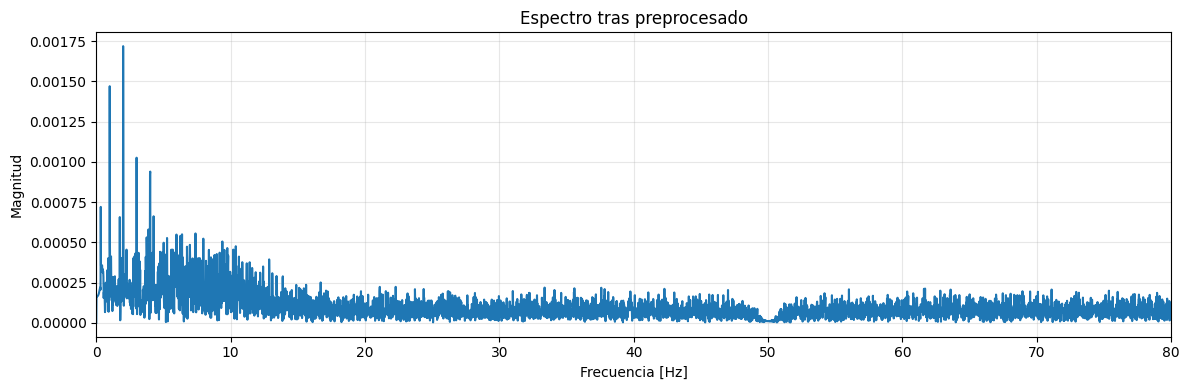

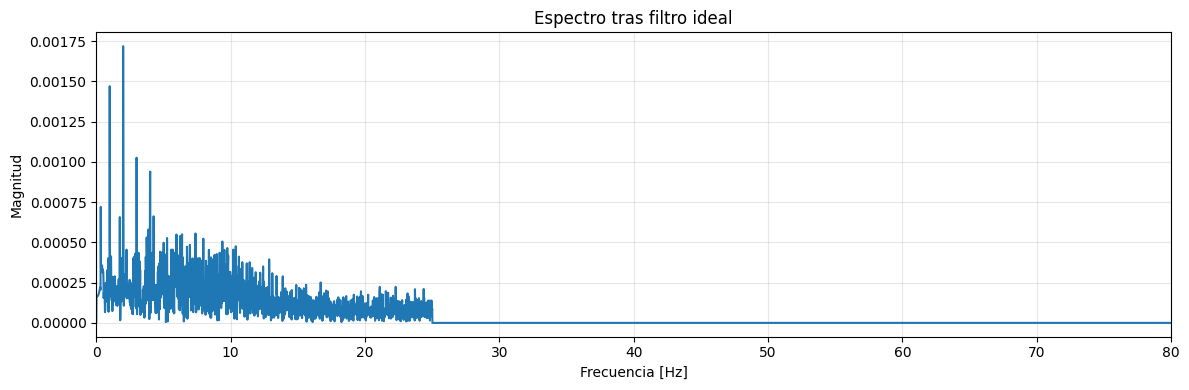

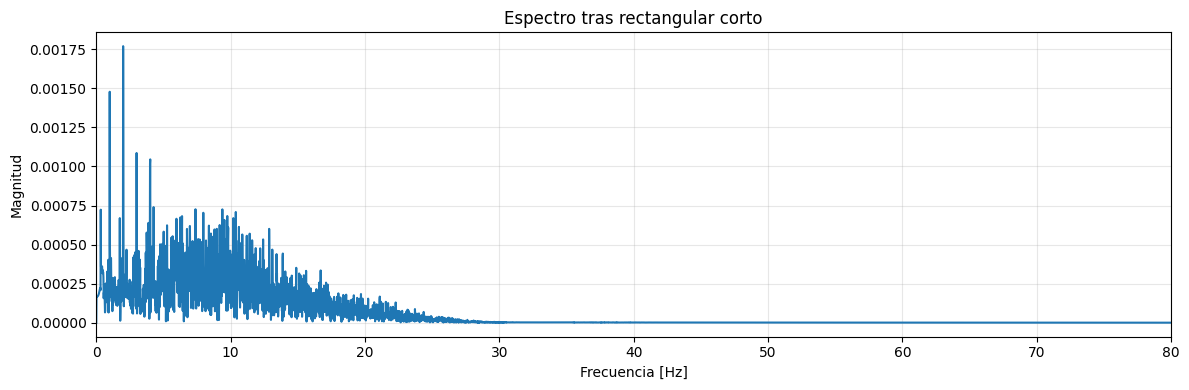

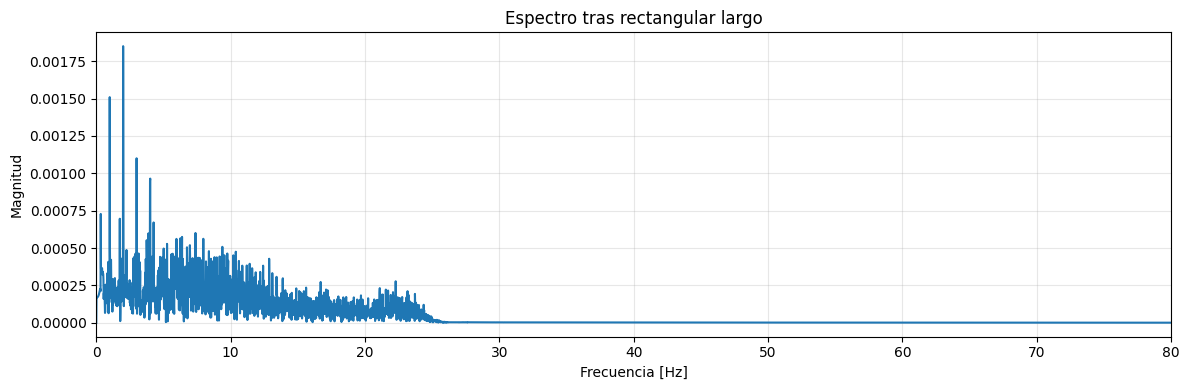

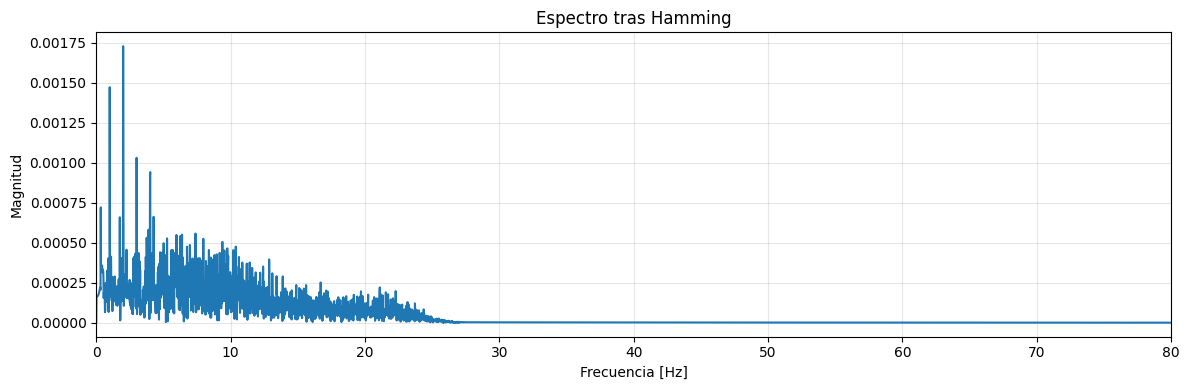

In [8]:
# Respuestas temporales / impulsionales de los filtros

# Respuesta temporal equivalente del filtro paso bajo definido en frecuencia
# Se obtiene como la transformada inversa de la máscara H_ideal.
h_pb_equiv = np.fft.irfft(H_ideal, n=len(ecg_preprocesado))

# Se centra para visualizar mejor su carácter oscilatorio alrededor de n = 0
h_pb_equiv_centrada = np.fft.fftshift(h_pb_equiv)
n_pb = np.arange(len(h_pb_equiv_centrada)) - len(h_pb_equiv_centrada)//2

# Ejes centrados para los filtros FIR
n_rect_corto = np.arange(len(h_rect_corto)) - (len(h_rect_corto)-1)//2
n_rect_largo = np.arange(len(h_rect_largo)) - (len(h_rect_largo)-1)//2
n_hamming = np.arange(len(h_hamming)) - (len(h_hamming)-1)//2

plt.figure(figsize=(12,4))

# Para que el paso bajo equivalente no aplaste visualmente los FIR,
# se muestra solo una ventana alrededor del centro.
ventana_pb = 300
centro_pb = len(h_pb_equiv_centrada)//2
idx_pb = slice(centro_pb - ventana_pb, centro_pb + ventana_pb + 1)

plt.plot(
    n_pb[idx_pb],
    h_pb_equiv_centrada[idx_pb],
    label="Paso bajo por FFT (equivalente finito)",
    linewidth=2
)

plt.plot(n_rect_corto, h_rect_corto, label="Rectangular corto")
plt.plot(n_rect_largo, h_rect_largo, label="Rectangular largo")
plt.plot(n_hamming, h_hamming, label="Hamming")

plt.title("Respuestas temporales de los filtros")
plt.xlabel("n centrado")
plt.ylabel("h[n]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Respuestas en frecuencia
plot_filter_response(h_rect_corto, fs, "Respuesta en frecuencia - rectangular corto")
plot_filter_response(h_rect_largo, fs, "Respuesta en frecuencia - rectangular largo")
plot_filter_response(h_hamming, fs, "Respuesta en frecuencia - Hamming")

# Comparación conjunta de respuestas en frecuencia
w_rect_corto, H_rect_corto = signal.freqz(h_rect_corto, worN=4096, fs=fs)
w_rect_largo, H_rect_largo = signal.freqz(h_rect_largo, worN=4096, fs=fs)
w_hamming, H_hamming = signal.freqz(h_hamming, worN=4096, fs=fs)

F_ideal = np.linspace(0, fs/2, 4096)
H_ideal_mag = (F_ideal <= fc_lp_hz).astype(float)

plt.figure(figsize=(12,4))
plt.plot(F_ideal, H_ideal_mag, label="Ideal")
plt.plot(w_rect_corto, np.abs(H_rect_corto), label="Rectangular corto")
plt.plot(w_rect_largo, np.abs(H_rect_largo), label="Rectangular largo")
plt.plot(w_hamming, np.abs(H_hamming), label="Hamming")
plt.axvline(fc_lp_hz, linestyle="--", label=f"F_pb = {fc_lp_hz} Hz")
plt.xlim(0, 80)
plt.ylim(-0.05, 1.3)
plt.title("Comparación de respuestas en frecuencia")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|H(F)|")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Comparaciones temporales
plt.figure(figsize=(12,5))
plt.plot(t, ecg_referencia, label="ECG limpio", linewidth=2)
plt.plot(t, ecg_preprocesado, label="Preprocesado", alpha=0.7)
plt.plot(t, ecg_ideal, label="Ideal", alpha=0.9)
plt.plot(t, ecg_rect_corto, label="Rectangular corto", alpha=0.9)
plt.plot(t, ecg_rect_largo, label="Rectangular largo", alpha=0.9)
plt.plot(t, ecg_hamming, label="Hamming", alpha=0.9)
plt.title("Comparación temporal de las señales filtradas")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [mV]")
plt.xlim(2, 8)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(t, ecg_referencia, label="ECG limpio", linewidth=2)
plt.plot(t, ecg_ideal, label="Ideal", alpha=0.9)
plt.plot(t, ecg_rect_corto, label="Rectangular corto", alpha=0.9)
plt.plot(t, ecg_rect_largo, label="Rectangular largo", alpha=0.9)
plt.plot(t, ecg_hamming, label="Hamming", alpha=0.9)
plt.title("Zoom temporal para observar distorsión y ringing")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [mV]")
plt.xlim(3.02, 3.20)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Comparaciones espectrales
plot_spectrum(ecg_preprocesado, fs, "Espectro tras preprocesado", fmax=80)
plot_spectrum(ecg_ideal, fs, "Espectro tras filtro ideal", fmax=80)
plot_spectrum(ecg_rect_corto, fs, "Espectro tras rectangular corto", fmax=80)
plot_spectrum(ecg_rect_largo, fs, "Espectro tras rectangular largo", fmax=80)
plot_spectrum(ecg_hamming, fs, "Espectro tras Hamming", fmax=80)

Las figuras muestran que las diferencias entre filtros no aparecen solo en el dominio frecuencial, sino también en el dominio temporal. El filtro de corte brusco actúa como referencia idealizada, mientras que los filtros FIR permiten estudiar cómo la longitud y la ventana modifican la respuesta temporal y la transición frecuencial.

En particular, el filtro rectangular largo aproxima mejor el corte paso bajo que el rectangular corto, pero presenta una respuesta temporal más extendida. La ventana de Hamming suaviza los coeficientes temporales y reduce parte de las oscilaciones asociadas al truncamiento rectangular, aunque a costa de una transición frecuencial más ancha.

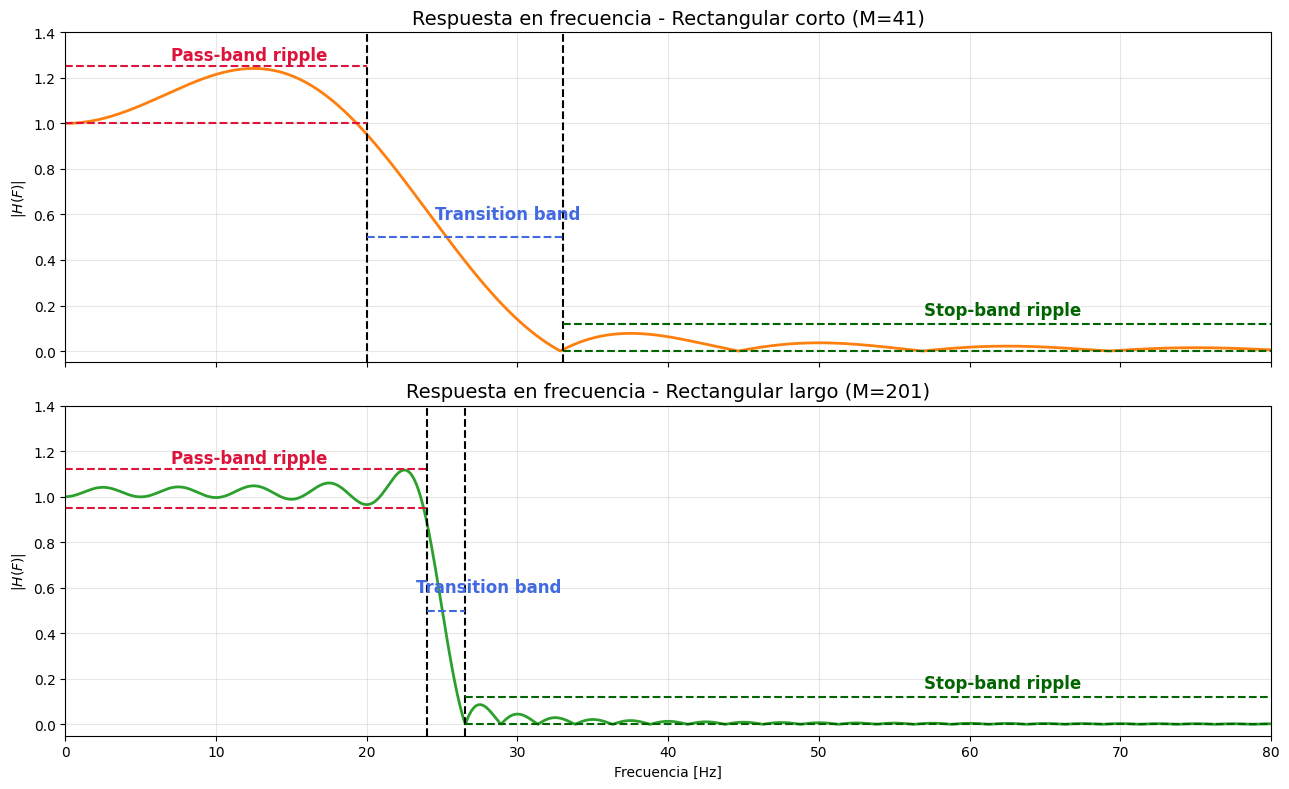

In [9]:
# ============================================================
# Figura explicativa de bandas y ripple
# usando los filtros del notebook
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ============================================================
# RESPUESTAS EN FRECUENCIA
# ============================================================

w_corto, H_corto = signal.freqz(h_rect_corto, worN=4096, fs=fs)
w_largo, H_largo = signal.freqz(h_rect_largo, worN=4096, fs=fs)

# ============================================================
# FIGURA
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

configs = [
    (
        axes[0],
        w_corto,
        np.abs(H_corto),
        "Rectangular corto (M=41)",
        "tab:orange",
        20,     # inicio transición
        33,     # fin transición
        1.25,   # pass-band ripple superior
        1.00    # pass-band ripple inferior
    ),
    (
        axes[1],
        w_largo,
        np.abs(H_largo),
        "Rectangular largo (M=201)",
        "tab:green",
        24,     # inicio transición
        26.5,   # fin transición
        1.12,   # pass-band ripple superior
        0.95    # pass-band ripple inferior
    )
]

for ax, w, H, titulo, color, f_pass, f_stop, ripple_sup, ripple_inf in configs:

    # curva
    ax.plot(w, H, color=color, linewidth=2)

    # líneas verticales
    ax.axvline(f_pass, color="black", linestyle="--", linewidth=1.5)
    ax.axvline(f_stop, color="black", linestyle="--", linewidth=1.5)

    # ========================================================
    # PASS BAND RIPPLE
    # ========================================================

    ax.plot(
        [0, f_pass],
        [ripple_sup, ripple_sup],
        color="crimson",
        linewidth=1.5,
        linestyle="--"
    )

    ax.plot(
        [0, f_pass],
        [ripple_inf, ripple_inf],
        color="crimson",
        linewidth=1.5,
        linestyle="--"
    )

    ax.text(
        7,
        ripple_sup + 0.03,
        "Pass-band ripple",
        color="crimson",
        fontsize=12,
        weight="bold"
    )

    # ========================================================
    # TRANSITION BAND
    # ========================================================

    ax.plot(
        [f_pass, f_stop],
        [0.50, 0.50],
        color="royalblue",
        linewidth=1.5,
        linestyle="--"
    )

    ax.text(
        (f_pass + f_stop) / 2 - 2,
        0.58,
        "Transition band",
        color="royalblue",
        fontsize=12,
        weight="bold"
    )

    # ========================================================
    # STOP BAND RIPPLE
    # ========================================================

    ax.plot(
        [f_stop, 80],
        [0.12, 0.12],
        color="darkgreen",
        linewidth=1.5,
        linestyle="--"
    )

    ax.plot(
        [f_stop, 80],
        [0.00, 0.00],
        color="darkgreen",
        linewidth=1.5,
        linestyle="--"
    )

    ax.text(
        57,
        0.16,
        "Stop-band ripple",
        color="darkgreen",
        fontsize=12,
        weight="bold"
    )

    # ========================================================
    # ESTILO
    # ========================================================

    ax.set_title(
        f"Respuesta en frecuencia - {titulo}",
        fontsize=14
    )

    ax.set_ylabel(r"$|H(F)|$")
    ax.set_xlim(0, 80)
    ax.set_ylim(-0.05, 1.4)

    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Frecuencia [Hz]")

plt.tight_layout()

plt.savefig(
    "bandas_ripple_rectangulares.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

La figura anterior resume las tres regiones principales de la respuesta en frecuencia de los filtros FIR rectangulares: banda de paso, banda de transición y banda de rechazo. Además, permite identificar el rizado en la banda de paso y en la banda de rechazo, asociado al truncamiento rectangular.

### 4.2 Evaluación cuantitativa del filtrado

Para complementar la inspección visual, se calculan métricas que comparan cada señal filtrada con el ECG limpio de referencia. Se incluyen tanto una métrica global, basada en el error punto a punto, como métricas morfológicas asociadas a rasgos concretos del latido:

- RMSE global respecto a la señal limpia;
- error temporal del pico R;
- error en la amplitud del pico R;
- error en la anchura aproximada del complejo QRS;
- error en una estimación práctica del intervalo QT.

Estas métricas no pretenden sustituir a un delineado clínico del ECG, sino proporcionar una forma consistente de comparar los filtros dentro del experimento.

In [10]:
def detectar_picos_r_referencia(ecg, fs):
    distancia_minima = int(0.5 * fs)
    altura_minima = 0.5 * np.max(ecg)
    picos, _ = find_peaks(ecg, distance=distancia_minima, height=altura_minima)
    return picos


def emparejar_picos_localmente(ecg, picos_ref, fs, ventana_ms=80):
    ventana = int((ventana_ms / 1000) * fs)
    picos_emp = []

    for p in picos_ref:
        ini = max(0, p - ventana)
        fin = min(len(ecg), p + ventana + 1)
        p_local = np.argmax(ecg[ini:fin]) + ini
        picos_emp.append(p_local)

    return np.array(picos_emp)


def anchura_qrs_media_altura(ecg, picos, fs):
    widths, _, _, _ = peak_widths(ecg, picos, rel_height=0.5)
    return widths / fs


def estimar_q_y_tfin(ecg, picos_R, fs, ventana_q_ms=80, ventana_t_ms=500, umbral_t=0.05):
    q_idx = []
    t_end_idx = []
    qt_s = []

    for r in picos_R:
        # Q: mínimo local antes de R
        wq = int((ventana_q_ms / 1000) * fs)
        ini_q = max(0, r - wq)
        fin_q = r
        if fin_q <= ini_q + 2:
            continue

        idx_q_local = np.argmin(ecg[ini_q:fin_q]) + ini_q

        # Fin de T: búsqueda local tras R
        wt = int((ventana_t_ms / 1000) * fs)
        ini_t = r + int(0.08 * fs)
        fin_t = min(len(ecg), r + wt)

        if fin_t <= ini_t + 5:
            continue

        segmento_t = ecg[ini_t:fin_t]
        baseline_local = np.median(ecg[max(0, r - int(0.2*fs)):min(len(ecg), r + int(0.2*fs))])
        idx_t_peak = np.argmax(np.abs(segmento_t - baseline_local)) + ini_t

        post_t = ecg[idx_t_peak:fin_t]
        cercanos = np.where(
            np.abs(post_t - baseline_local) <= umbral_t * np.max(np.abs(segmento_t - baseline_local))
        )[0]

        if len(cercanos) == 0:
            idx_t_end = fin_t - 1
        else:
            idx_t_end = idx_t_peak + cercanos[0]

        if idx_t_end > idx_q_local:
            q_idx.append(idx_q_local)
            t_end_idx.append(idx_t_end)
            qt_s.append((idx_t_end - idx_q_local) / fs)

    return np.array(q_idx), np.array(t_end_idx), np.array(qt_s)


def medir_senal(ecg_filtrada, ecg_ref, picos_ref, fs):
    picos_filtrados = emparejar_picos_localmente(ecg_filtrada, picos_ref, fs)

    t_ref = picos_ref / fs
    t_fil = picos_filtrados / fs
    amp_ref = ecg_ref[picos_ref]
    amp_fil = ecg_filtrada[picos_filtrados]

    qrs_ref = anchura_qrs_media_altura(ecg_ref, picos_ref, fs)
    qrs_fil = anchura_qrs_media_altura(ecg_filtrada, picos_filtrados, fs)

    q_ref, tfin_ref, qt_ref = estimar_q_y_tfin(ecg_ref, picos_ref, fs)
    q_fil, tfin_fil, qt_fil = estimar_q_y_tfin(ecg_filtrada, picos_ref, fs)

    n_qt = min(len(qt_ref), len(qt_fil))

    return {
        "rmse_global": rmse(ecg_filtrada, ecg_ref),
        "error_tiempo_R": t_fil - t_ref,
        "error_amp_R": amp_fil - amp_ref,
        "error_qrs": qrs_fil - qrs_ref,
        "qt_ref": qt_ref[:n_qt],
        "qt_fil": qt_fil[:n_qt],
        "mae_qt_ms": 1000 * np.mean(np.abs(qt_fil[:n_qt] - qt_ref[:n_qt])) if n_qt > 0 else np.nan
    }

Las funciones anteriores implementan una estrategia práctica para extraer medidas morfológicas comparables entre la señal de referencia y las señales filtradas. En concreto, primero se detectan los picos R sobre la señal limpia de referencia y, a partir de ellos, se buscan los picos correspondientes en cada señal filtrada. Después se calculan distintas métricas de error asociadas a la posición temporal de R, su amplitud, una estimación de la anchura del QRS y una estimación práctica del intervalo QT.

#### 4.2.1 Validación de la detección sobre la señal de referencia

Antes de comparar cuantitativamente los filtros, se comprueba sobre la señal limpia de referencia que la detección de los puntos R, Q y del final de T es razonable. Esto permite verificar que el procedimiento utilizado para estimar el intervalo QT y otros rasgos morfológicos funciona de forma coherente sobre el ECG generado por el modelo.

Además, se representa la relación QT–RR en la señal de referencia como comprobación adicional de que la variabilidad introducida en el modelo produce cambios temporales razonables entre latidos.

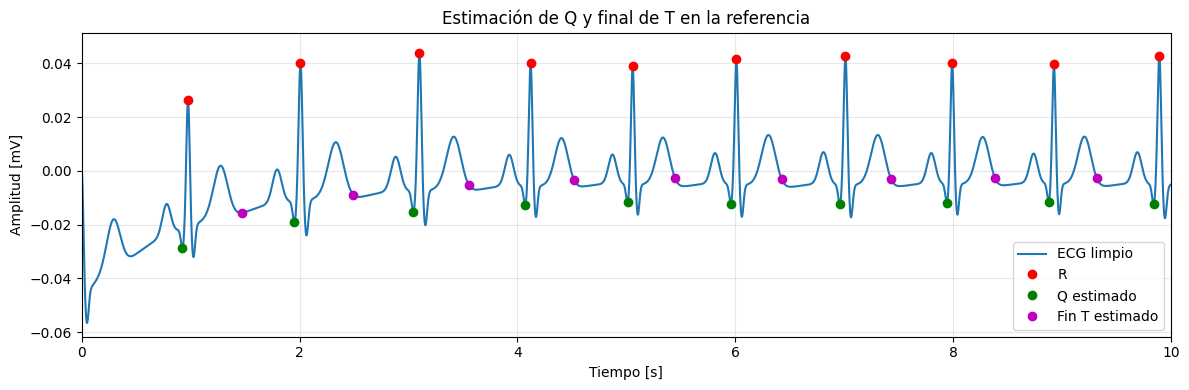

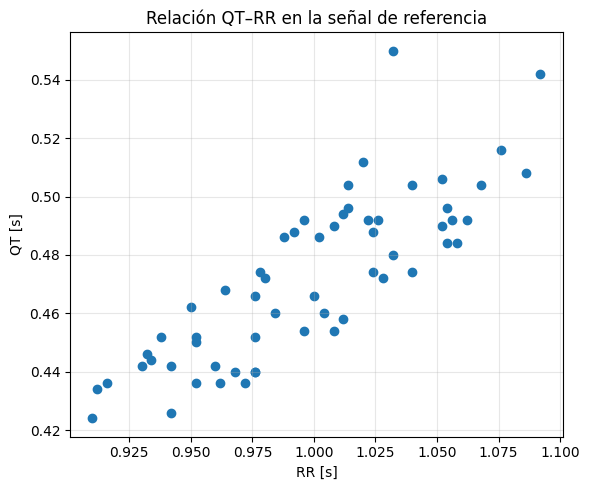

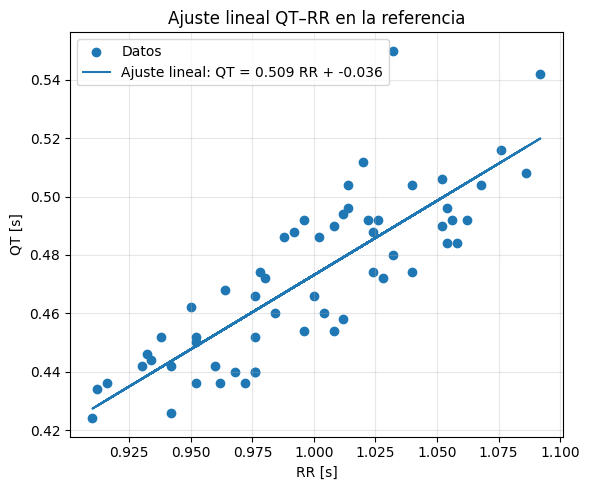

In [11]:
# Picos R de referencia
picos_ref = detectar_picos_r_referencia(ecg_referencia, fs)

# Validación QT–RR en la referencia
q_ref, tfin_ref, qt_ref = estimar_q_y_tfin(ecg_referencia, picos_ref, fs)
rr_ref = np.diff(picos_ref) / fs

n_qt = min(len(qt_ref), len(rr_ref))
qt_ref = qt_ref[:n_qt]
rr_ref_qt = rr_ref[:n_qt]

plt.figure(figsize=(12,4))
plt.plot(t, ecg_referencia, label="ECG limpio")
plt.plot(t[picos_ref], ecg_referencia[picos_ref], 'ro', label='R')
plt.plot(t[q_ref], ecg_referencia[q_ref], 'go', label='Q estimado')
plt.plot(t[tfin_ref], ecg_referencia[tfin_ref], 'mo', label='Fin T estimado')
plt.title("Estimación de Q y final de T en la referencia")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [mV]")
plt.xlim(0, 10)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(rr_ref_qt, qt_ref)
plt.title("Relación QT–RR en la señal de referencia")
plt.xlabel("RR [s]")
plt.ylabel("QT [s]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

coef_ref = np.polyfit(rr_ref_qt, qt_ref, 1)
qt_fit_ref = np.polyval(coef_ref, rr_ref_qt)

plt.figure(figsize=(6,5))
plt.scatter(rr_ref_qt, qt_ref, label='Datos')
plt.plot(rr_ref_qt, qt_fit_ref, label=f'Ajuste lineal: QT = {coef_ref[0]:.3f} RR + {coef_ref[1]:.3f}')
plt.title("Ajuste lineal QT–RR en la referencia")
plt.xlabel("RR [s]")
plt.ylabel("QT [s]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Las gráficas anteriores muestran que la estimación de los puntos Q y del final de T sobre la señal de referencia es suficientemente coherente para este experimento. Además, la relación QT–RR muestra que el intervalo QT varía de un latido a otro en función del intervalo RR, lo que aporta consistencia al ECG sintético utilizado como referencia.

Estas detecciones son aproximadas, pero permiten comparar de forma homogénea cómo los distintos filtros modifican rasgos temporales relevantes de la señal.

#### 4.2.2 Métricas comparativas del filtrado

In [12]:
# Medidas para todas las señales
metricas = {}
for nombre, senal in senales_a_comparar.items():
    metricas[nombre] = medir_senal(senal, ecg_referencia, picos_ref, fs)

# Tabla resumen
resumen = []
for nombre, m in metricas.items():
    resumen.append({
        "Filtro": nombre,
        "RMSE_global": m["rmse_global"],
        "MAE_tiempo_R_ms": 1000 * np.mean(np.abs(m["error_tiempo_R"])),
        "MAE_amp_R_mV": np.mean(np.abs(m["error_amp_R"])),
        "MAE_QRS_ms": 1000 * np.mean(np.abs(m["error_qrs"])),
        "MAE_QT_ms": m["mae_qt_ms"]
    })

tabla_resumen = pd.DataFrame(resumen)
tabla_resumen = tabla_resumen.sort_values("RMSE_global")
tabla_resumen

,Filtro,RMSE_global,MAE_tiempo_R_ms,MAE_amp_R_mV,MAE_QRS_ms,MAE_QT_ms
5,Hamming,0.005974,1.900000,0.004374,4.501646,35.066667
2,Ideal,0.006100,1.966667,0.004486,4.593281,37.066667
4,Rectangular largo,0.006262,2.066667,0.004641,4.677873,33.666667
3,Rectangular corto,0.007310,1.733333,0.012697,3.312913,49.833333
1,Preprocesado,0.015424,5.900000,0.019623,7.748116,105.733333
0,Ruidoso,0.028142,5.766667,0.028381,17.713358,97.166667


Las funciones anteriores permiten complementar la inspección visual con una evaluación cuantitativa de la distorsión introducida por cada etapa de filtrado. A partir de los picos R detectados en la señal limpia de referencia, se localizan los picos correspondientes en cada señal comparada y se calculan varias métricas: error global respecto a la referencia, error en el tiempo y en la amplitud del pico R, error en una estimación simple de la anchura del QRS y error en una estimación práctica del intervalo QT. La tabla resumen reúne estas medidas para todas las señales y permite comparar de forma objetiva hasta qué punto cada filtro preserva la morfología temporal del ECG.

Los resultados muestran que todas las versiones filtradas mejoran claramente respecto a la señal ruidosa y también respecto a la señal únicamente preprocesada. La señal ruidosa presenta un RMSE global de $0.028142$, mientras que la señal preprocesada reduce este valor a $0.015424$. Tras aplicar los filtros paso bajo, el error global disminuye todavía más, situándose aproximadamente entre $0.006$ y $0.007$.

En términos de RMSE global, el mejor resultado corresponde al filtro Hamming, con $RMSE=0.005974$, seguido por el filtro ideal y el rectangular largo. Además, Hamming obtiene el menor error de amplitud del pico R, $0.004374\,\mathrm{mV}$, y el rectangular corto obtiene la menor estimación de error en anchura del QRS, $3.31\,\mathrm{ms}$. Sin embargo, el rectangular corto presenta un error de amplitud del pico R mayor que el resto de filtros paso bajo, por lo que no puede considerarse superior en todas las métricas.

En conjunto, la tabla muestra que no existe un filtro que sea mejor en todos los indicadores. Por este motivo, se utiliza posteriormente un `score_global`, que combina las métricas normalizadas y permite valorar el compromiso global entre reducción de ruido y preservación morfológica.

### 4.3 Síntesis del experimento principal y análisis separado de parámetros

A partir de las métricas calculadas en la sección anterior, se resume primero la comparación general entre las señales consideradas: señal ruidosa, señal preprocesada, filtro ideal y filtros FIR prácticos. El filtro ideal se mantiene como referencia teórica, mientras que los filtros rectangular corto, rectangular largo y Hamming se interpretan como aproximaciones FIR realizables.

Para evitar mezclar varios efectos en una única comparación, el análisis se organiza después en tres experimentos:

1. **Efecto de la longitud \(M\)**: se comparan los filtros rectangulares corto y largo. Ambos usan truncamiento rectangular de la sinc ideal y solo cambia la longitud del filtro.

2. **Efecto de la ventana**: se comparan el filtro rectangular largo y el filtro Hamming. Ambos usan la misma longitud \(M=201\), pero cambia la ventana aplicada.

3. **Efecto de la frecuencia de corte $F_{\mathrm{pb}}$**: se fija el filtro Hamming con \(M=201\) y se prueban distintas frecuencias de corte para estudiar el compromiso entre suavizado y preservación morfológica.

El objetivo no es declarar un filtro óptimo universal, sino observar cómo cada decisión de diseño afecta a las métricas y a la forma temporal del ECG.

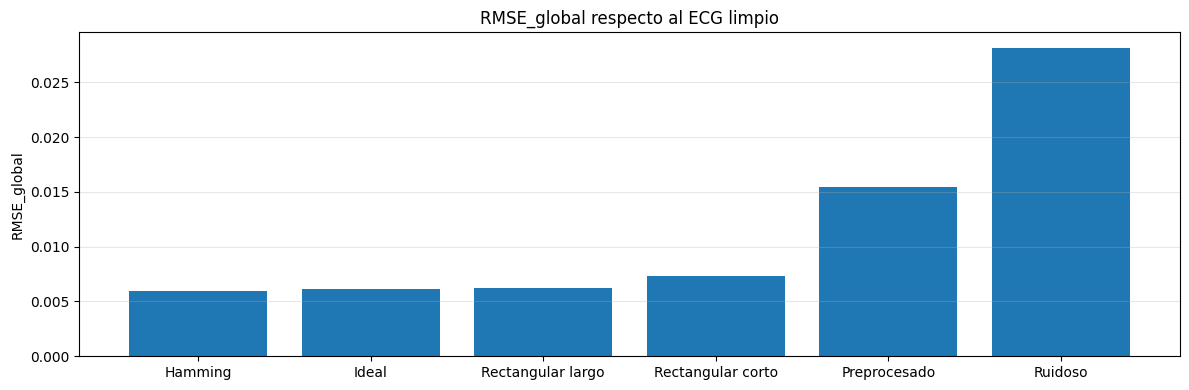

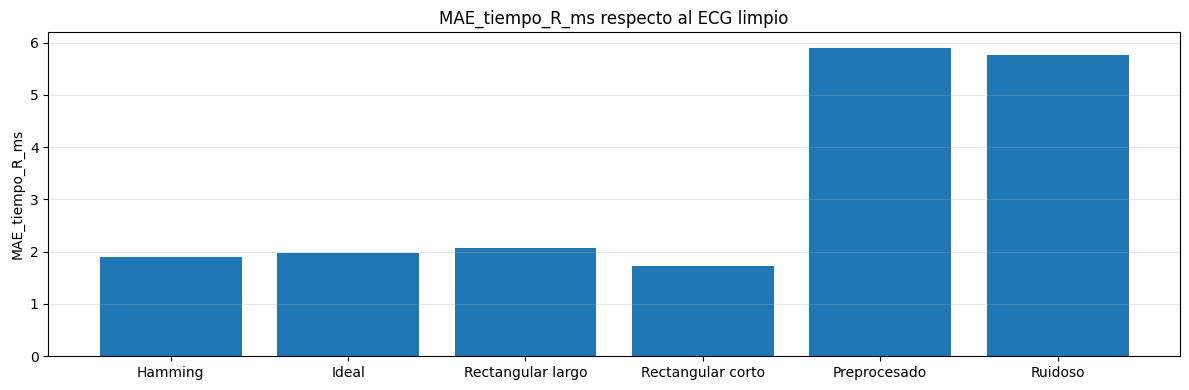

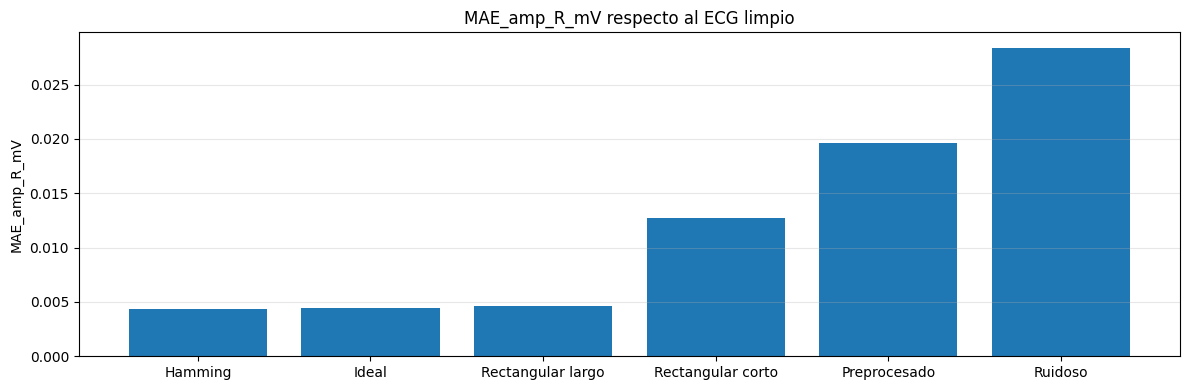

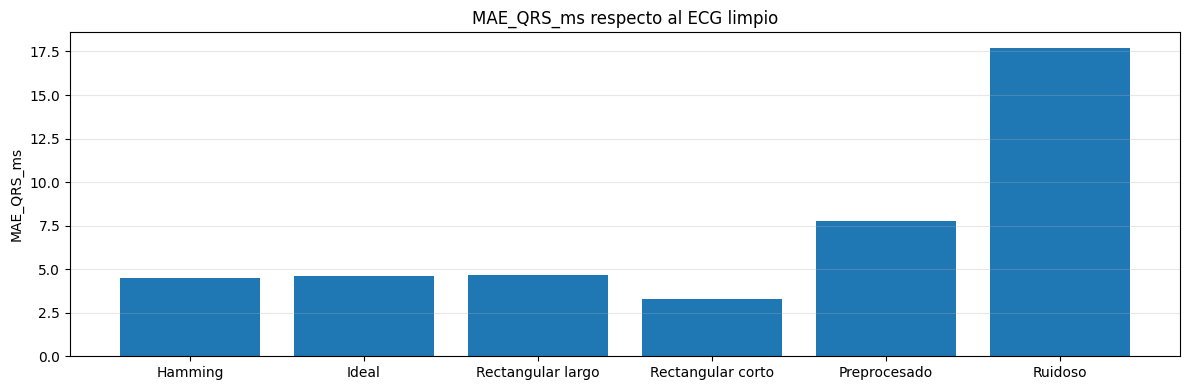

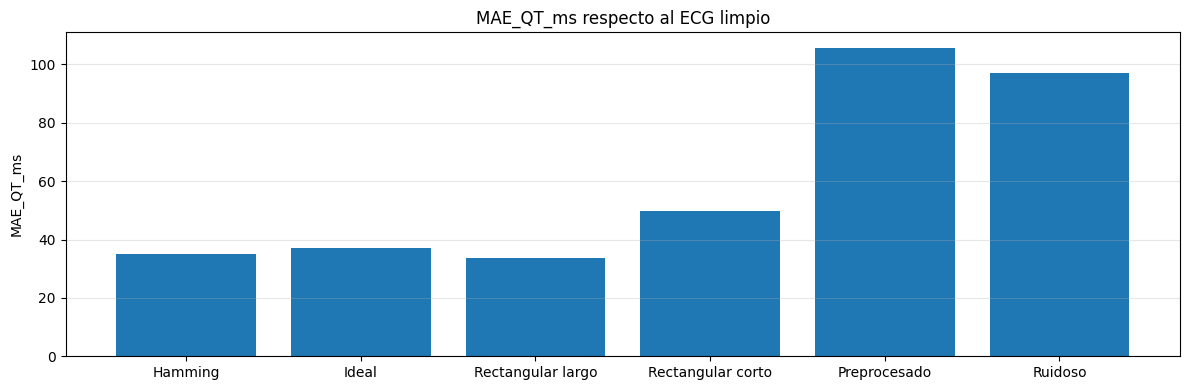

,Filtro,score_global
0,Hamming,0.028395
1,Rectangular largo,0.039772
2,Ideal,0.040478
3,Rectangular corto,0.126250
4,Preprocesado,0.673884
5,Ruidoso,0.969826


Mejor compromiso global según el score definido en el notebook: Hamming


,Filtro,score_global
0,Hamming,0.028395
1,Rectangular largo,0.039772
2,Rectangular corto,0.126250


Mejor compromiso práctico entre filtros FIR según el mismo score: Hamming


In [13]:
# ============================================================
# 4.3 Síntesis general de métricas
# ============================================================

metric_cols = ["RMSE_global", "MAE_tiempo_R_ms", "MAE_amp_R_mV", "MAE_QRS_ms", "MAE_QT_ms"]

# Gráficas de barras para todas las señales comparadas
for col in metric_cols:
    plt.figure(figsize=(12,4))
    plt.bar(tabla_resumen["Filtro"], tabla_resumen[col])
    plt.title(f"{col} respecto al ECG limpio")
    plt.ylabel(col)
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Score global general, manteniendo Ideal, Ruidoso y Preprocesado como referencias
tabla_score = tabla_resumen.copy()

for col in metric_cols:
    mn = tabla_score[col].min()
    mx = tabla_score[col].max()
    if mx > mn:
        tabla_score[col + "_norm"] = (tabla_score[col] - mn) / (mx - mn)
    else:
        tabla_score[col + "_norm"] = 0.0

tabla_score["score_global"] = tabla_score[[c + "_norm" for c in metric_cols]].mean(axis=1)
tabla_score = tabla_score.sort_values("score_global").reset_index(drop=True)

display(tabla_score[["Filtro", "score_global"]])

mejor_filtro_global = tabla_score.iloc[0]["Filtro"]
print("Mejor compromiso global según el score definido en el notebook:", mejor_filtro_global)

# Tabla solo de filtros FIR prácticos, sin recalcular el score
tabla_score_practicos = (
    tabla_score[tabla_score["Filtro"].isin(filtros_practicos)]
    .sort_values("score_global")
    .reset_index(drop=True)
)

display(tabla_score_practicos[["Filtro", "score_global"]])

mejor_filtro_practico = tabla_score_practicos.iloc[0]["Filtro"]
print("Mejor compromiso práctico entre filtros FIR según el mismo score:", mejor_filtro_practico)

tabla_resumen.to_csv("resumen_metricas_filtros.csv", index=False)
tabla_score.to_csv("resumen_score_filtros.csv", index=False)
tabla_score_practicos.to_csv("resumen_score_filtros_practicos.csv", index=False)

Los resultados globales muestran que los filtros reducen claramente el error respecto a la señal ruidosa y a la señal únicamente preprocesada. Esto confirma que el filtrado paso bajo posterior al preprocesado contribuye a acercar la señal contaminada a la referencia limpia.

El menor `score_global` lo obtiene el filtro Hamming, seguido por el filtro rectangular largo y por el filtro ideal, con valores bastante próximos entre sí. Esta cercanía indica que, para esta señal sintética y estos parámetros, los filtros FIR prácticos consiguen aproximarse bastante al comportamiento de la referencia ideal. No obstante, el filtro ideal debe interpretarse solo como referencia teórica de corte abrupto, no como una implementación FIR realizable.

Al restringir la comparación a los filtros FIR prácticos, Hamming obtiene el mejor compromiso global según las métricas normalizadas. El filtro rectangular largo queda relativamente próximo, mientras que el rectangular corto presenta un `score_global` claramente mayor. Por tanto, este resultado no debe interpretarse como una conclusión universal, sino como el mejor compromiso dentro de este experimento concreto.

#### 4.3.1 Experimento 1: efecto de la longitud del filtro rectangular

En este experimento se comparan los dos filtros rectangulares definidos previamente: el filtro rectangular corto y el filtro rectangular largo. Ambos se construyen truncando la respuesta impulsional ideal tipo sinc con una ventana rectangular. Por tanto, la diferencia principal entre ellos es la longitud $M$.

El filtro corto tiene una respuesta impulsional más localizada en el tiempo, mientras que el filtro largo aproxima mejor el corte frecuencial ideal, pero posee una respuesta temporal más extendida. Esta comparación permite estudiar el efecto de la longitud del truncamiento sobre la morfología del ECG.

,Filtro,RMSE_global,MAE_tiempo_R_ms,MAE_amp_R_mV,MAE_QRS_ms,MAE_QT_ms
4,Rectangular largo,0.006262,2.066667,0.004641,4.677873,33.666667
3,Rectangular corto,0.007310,1.733333,0.012697,3.312913,49.833333


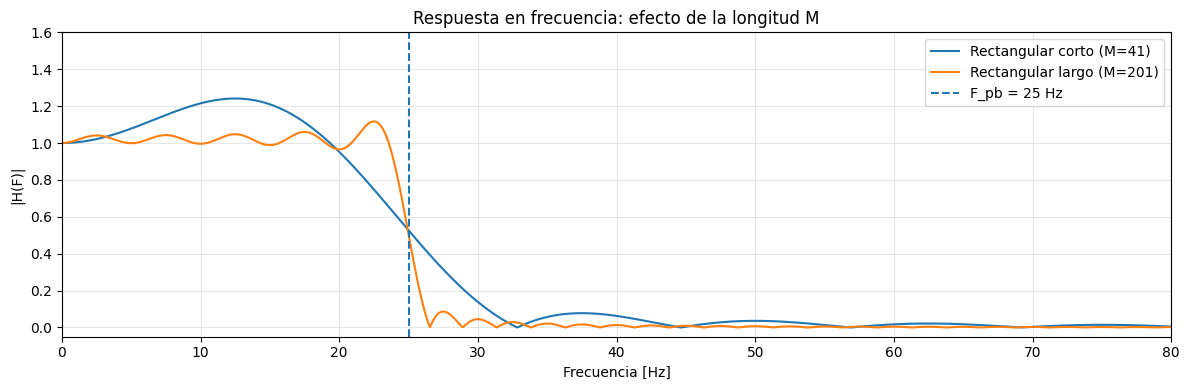

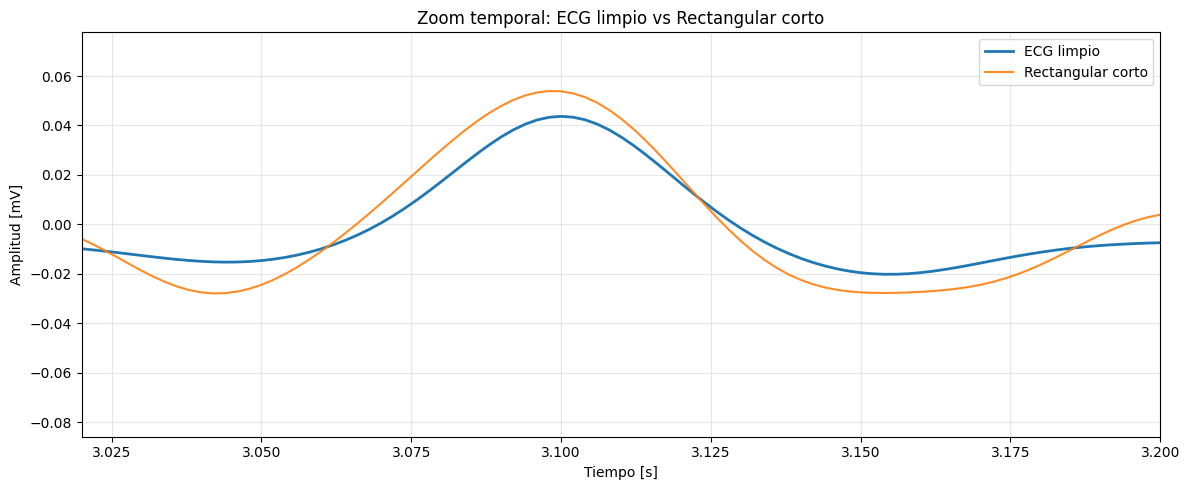

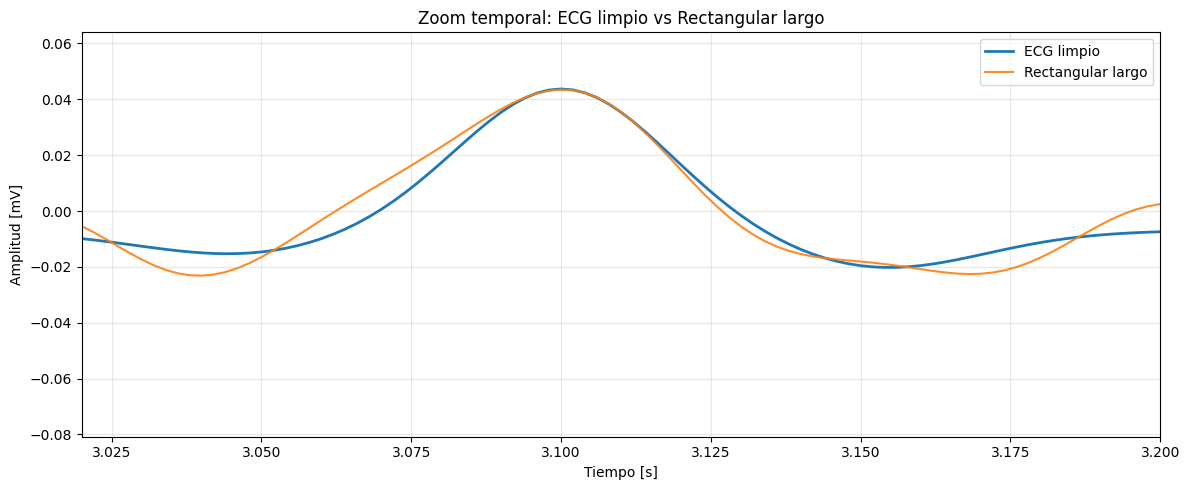

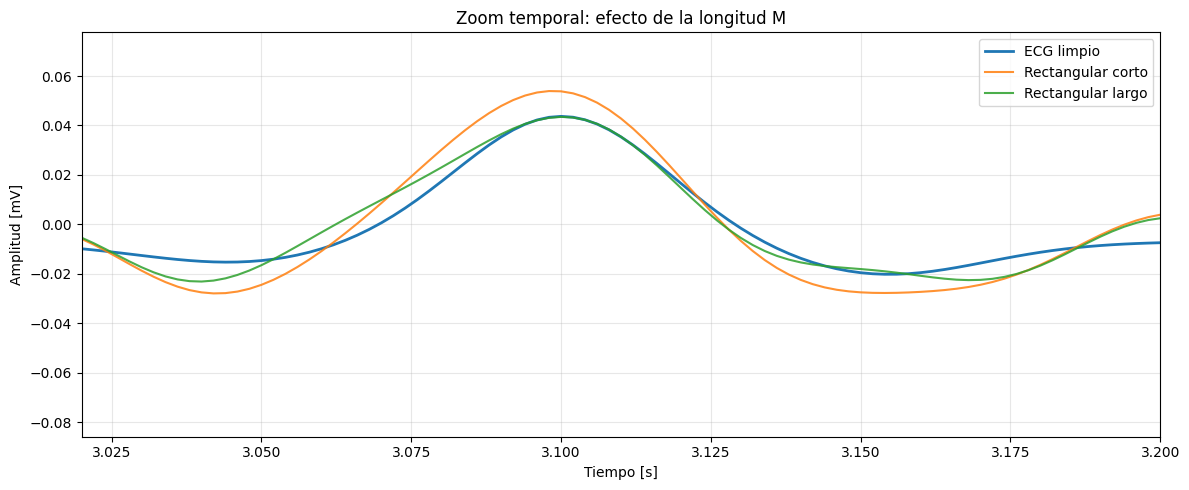

In [14]:
# ============================================================
# Experimento 1: efecto de la longitud M
# Rectangular corto vs rectangular largo
# ============================================================

senales_exp_M = {
    "Rectangular corto": ecg_rect_corto,
    "Rectangular largo": ecg_rect_largo
}

filtros_exp_M = {
    f"Rectangular corto (M={M_corto})": h_rect_corto,
    f"Rectangular largo (M={M_largo})": h_rect_largo
}

tabla_exp_M = tabla_resumen[
    tabla_resumen["Filtro"].isin(["Rectangular corto", "Rectangular largo"])
].copy()

display(tabla_exp_M)

# Respuesta en frecuencia
plt.figure(figsize=(12,4))
for nombre, h in filtros_exp_M.items():
    w, H = signal.freqz(h, worN=4096, fs=fs)
    plt.plot(w, np.abs(H), label=nombre)

plt.axvline(fc_lp_hz, linestyle="--", label=f"F_pb = {fc_lp_hz} Hz")
plt.xlim(0, 80)
plt.ylim(-0.05, 1.6)
plt.title("Respuesta en frecuencia: efecto de la longitud M")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|H(F)|")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Zoom individual
for nombre, senal in senales_exp_M.items():
    plt.figure(figsize=(12,5))
    plt.plot(t, ecg_referencia, label="ECG limpio", linewidth=2)
    plt.plot(t, senal, label=nombre, alpha=0.9)
    plt.title(f"Zoom temporal: ECG limpio vs {nombre}")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud [mV]")
    plt.xlim(3.02, 3.20)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Zoom conjunto
plt.figure(figsize=(12,5))
plt.plot(t, ecg_referencia, label="ECG limpio", linewidth=2)

for nombre, senal in senales_exp_M.items():
    plt.plot(t, senal, label=nombre, alpha=0.85)

plt.title("Zoom temporal: efecto de la longitud M")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [mV]")
plt.xlim(3.02, 3.20)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

tabla_exp_M.to_csv("resumen_experimento_longitud_M.csv", index=False)

El filtro rectangular largo presenta menor RMSE global, menor error de amplitud del pico R y menor error en el intervalo QT. En cambio, el filtro rectangular corto obtiene mejores valores en el error temporal del pico R y en la anchura aproximada del QRS.

Esto muestra que aumentar la longitud $M$ no mejora todas las métricas de forma simultánea. El filtro largo es más selectivo en frecuencia, pero su respuesta temporal es más extensa; por ello, puede mejorar algunos indicadores globales o de amplitud y empeorar ligeramente otros rasgos morfológicos locales.

En frecuencia se observa que el filtro rectangular largo tiene una transición más estrecha que el filtro corto. Por tanto, se comporta como un filtro más selectivo y más próximo al paso bajo ideal.

Sin embargo, esta mayor selectividad no implica necesariamente una mejora global en la señal filtrada. Los resultados numéricos muestran que la mejora frecuencial puede venir acompañada de cambios temporales que afectan de forma distinta a cada métrica morfológica.

En el zoom temporal, las diferencias entre rectangular corto y rectangular largo son pequeñas, aunque se aprecian ligeras variaciones alrededor de las zonas rápidas del ECG. Ambos filtros siguen de forma razonable la referencia limpia, pero no se comportan exactamente igual.

Esto justifica el uso de métricas cuantitativas: visualmente las diferencias son sutiles, pero numéricamente se observa que cada longitud favorece unas medidas distintas.

#### 4.3.2 Experimento 2: efecto de la ventana

En este experimento se fija la longitud del filtro en $M=201$ para aislar el efecto de la ventana, ya que la influencia de la longitud se ha estudiado en el experimento anterior. Se comparan el filtro rectangular largo y el filtro Hamming, ambos construidos con la misma longitud, de modo que las diferencias observadas no se deben a la duración del filtro, sino al tipo de ventana aplicado al truncamiento de la sinc ideal. El filtro rectangular largo corresponde a un truncamiento brusco, mientras que el filtro Hamming suaviza los extremos de la respuesta impulsional. Se elige $M=201$ porque una longitud mayor permite apreciar con más claridad el efecto de la ventana sobre el rizado, la banda de transición y la preservación temporal de la señal.

,Filtro,RMSE_global,MAE_tiempo_R_ms,MAE_amp_R_mV,MAE_QRS_ms,MAE_QT_ms
5,Hamming,0.005974,1.900000,0.004374,4.501646,35.066667
4,Rectangular largo,0.006262,2.066667,0.004641,4.677873,33.666667


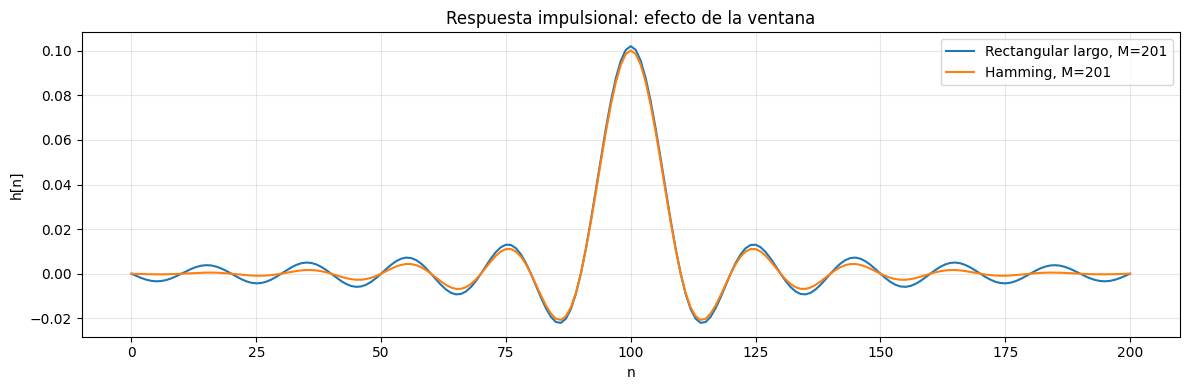

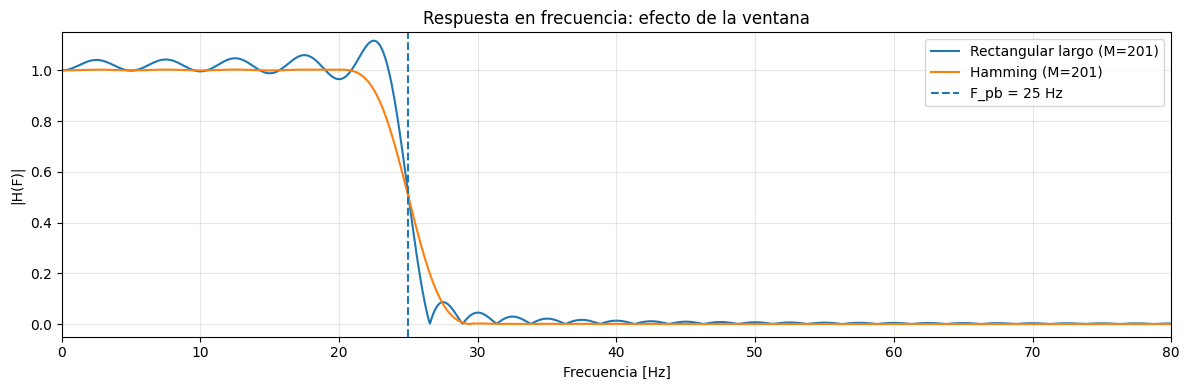

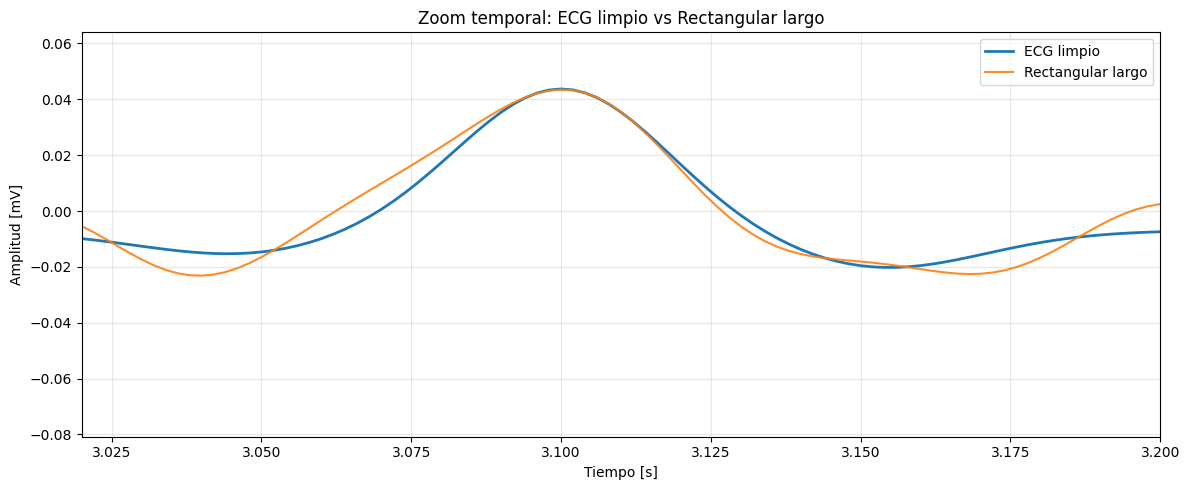

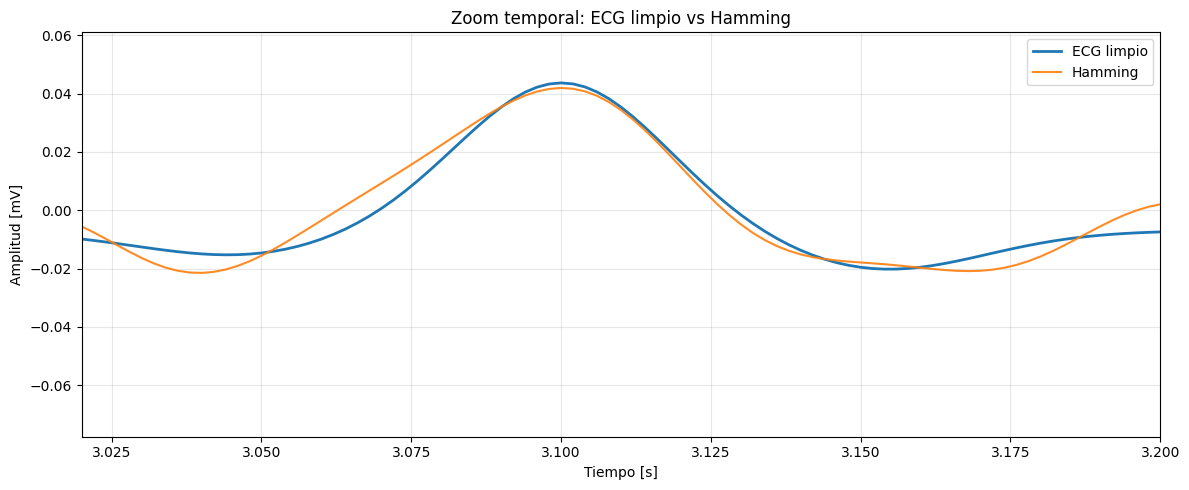

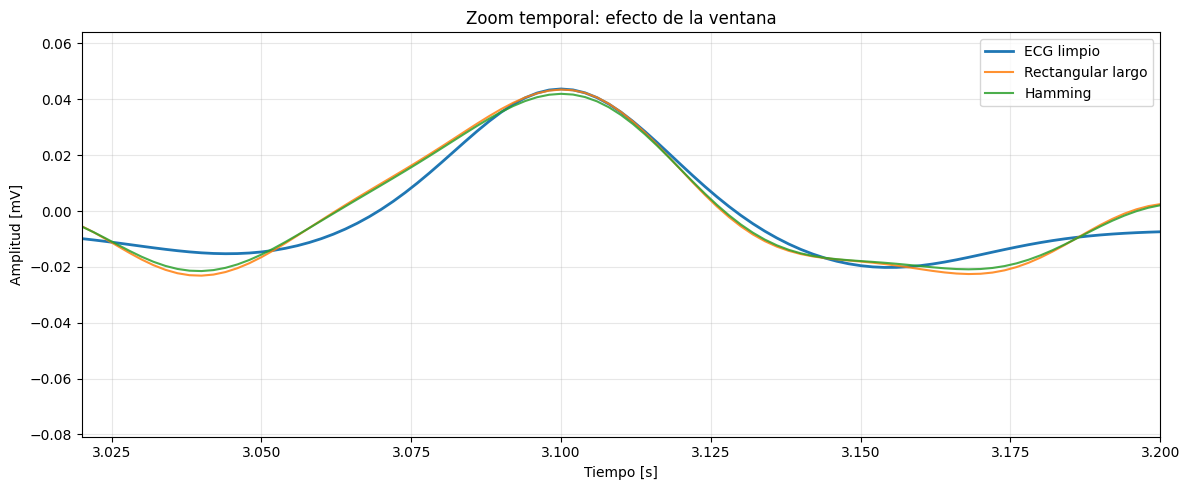

In [15]:
# ============================================================
# Experimento 2: efecto de la ventana
# Rectangular largo vs Hamming, ambos con M=201
# ============================================================

senales_exp_ventana = {
    "Rectangular largo": ecg_rect_largo,
    "Hamming": ecg_hamming
}

filtros_exp_ventana = {
    f"Rectangular largo (M={M_largo})": h_rect_largo,
    f"Hamming (M={M_largo})": h_hamming
}

tabla_exp_ventana = tabla_resumen[
    tabla_resumen["Filtro"].isin(["Rectangular largo", "Hamming"])
].copy()

display(tabla_exp_ventana)

# Respuesta impulsional
plt.figure(figsize=(12,4))
plt.plot(h_rect_largo, label=f"Rectangular largo, M={M_largo}")
plt.plot(h_hamming, label=f"Hamming, M={M_largo}")
plt.title("Respuesta impulsional: efecto de la ventana")
plt.xlabel("n")
plt.ylabel("h[n]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Respuesta en frecuencia
plt.figure(figsize=(12,4))
for nombre, h in filtros_exp_ventana.items():
    w, H = signal.freqz(h, worN=4096, fs=fs)
    plt.plot(w, np.abs(H), label=nombre)

plt.axvline(fc_lp_hz, linestyle="--", label=f"F_pb = {fc_lp_hz} Hz")
plt.xlim(0, 80)
plt.ylim(-0.05, 1.15)
plt.title("Respuesta en frecuencia: efecto de la ventana")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|H(F)|")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Zoom individual
for nombre, senal in senales_exp_ventana.items():
    plt.figure(figsize=(12,5))
    plt.plot(t, ecg_referencia, label="ECG limpio", linewidth=2)
    plt.plot(t, senal, label=nombre, alpha=0.9)
    plt.title(f"Zoom temporal: ECG limpio vs {nombre}")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud [mV]")
    plt.xlim(3.02, 3.20)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Zoom conjunto
plt.figure(figsize=(12,5))
plt.plot(t, ecg_referencia, label="ECG limpio", linewidth=2)

for nombre, senal in senales_exp_ventana.items():
    plt.plot(t, senal, label=nombre, alpha=0.85)

plt.title("Zoom temporal: efecto de la ventana")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [mV]")
plt.xlim(3.02, 3.20)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

tabla_exp_ventana.to_csv("resumen_experimento_ventana.csv", index=False)

Los resultados del experimento muestran que ambos filtros producen un comportamiento muy parecido, lo cual es coherente con que los dos parten de la misma respuesta ideal y tienen la misma longitud \(M=201\). La diferencia principal está en la ventana utilizada:

- En el dominio temporal, la ventana Hamming suaviza los extremos del filtro respecto al truncamiento rectangular. En lugar de cortar la sinc de forma brusca, reduce progresivamente el peso de los coeficientes hacia los extremos.

- En el dominio frecuencial, este suavizado tiende a reducir el rizado asociado al truncamiento rectangular, aunque a costa de una transición algo más ancha. Esto refleja el compromiso clásico del diseño mediante ventanas: reducir las oscilaciones implica perder algo de brusquedad en la transición.

- En la señal ECG filtrada, rectangular largo y Hamming producen resultados muy similares. Aun así, Hamming mejora ligeramente el RMSE global, el error de amplitud del pico R y la anchura aproximada del QRS. En cambio, el rectangular largo obtiene un valor ligeramente menor en el error del intervalo QT.

En conjunto, Hamming obtiene un `score_global` ligeramente mejor en esta comparación práctica. Por tanto, su ventaja existe, pero debe interpretarse como una mejora moderada en la preservación morfológica, no como un cambio radical respecto al filtro rectangular largo.

#### 4.3.3 Experimento 3: efecto de la frecuencia de corte

En este experimento se fija el tipo de filtro y la longitud, y se modifica únicamente la frecuencia de corte $F_{\mathrm{pb}}$. Se utiliza el filtro Hamming con $M=201$, y se comparan tres valores: $F_{\mathrm{pb}}=20\,\mathrm{Hz}$, $F_{\mathrm{pb}}=35\,\mathrm{Hz}$ y $F_{\mathrm{pb}}=50\,\mathrm{Hz}$.

,Filtro,F_pb_Hz,RMSE_global,MAE_tiempo_R_ms,MAE_amp_R_mV,MAE_QRS_ms,MAE_QT_ms
0,Hamming F_pb=20 Hz,20,0.005558,1.566667,0.004349,5.177439,39.233333
1,Hamming F_pb=35 Hz,35,0.006712,3.200000,0.004967,5.170580,43.400000
2,Hamming F_pb=50 Hz,50,0.007623,4.166667,0.005622,5.728688,52.200000


,Filtro,F_pb_Hz,score_global
0,Hamming F_pb=20 Hz,20,0.002458
1,Hamming F_pb=35 Hz,35,0.398804
2,Hamming F_pb=50 Hz,50,1.000000


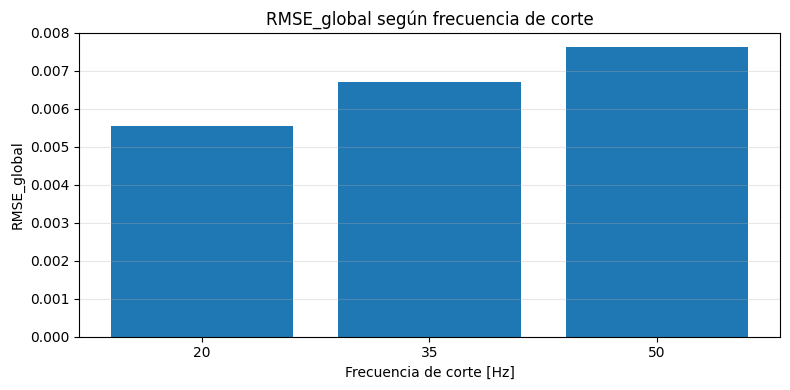

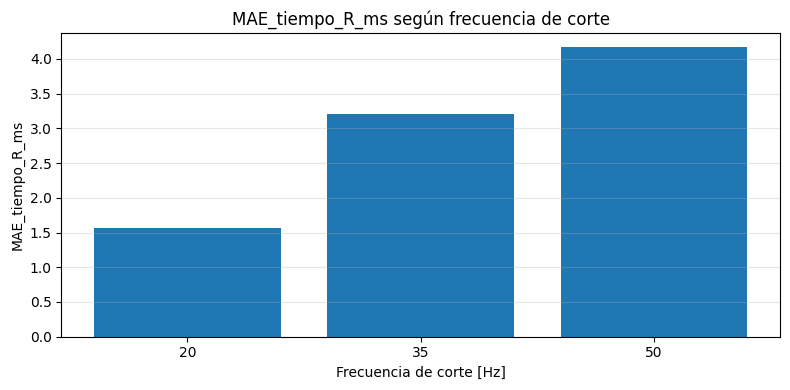

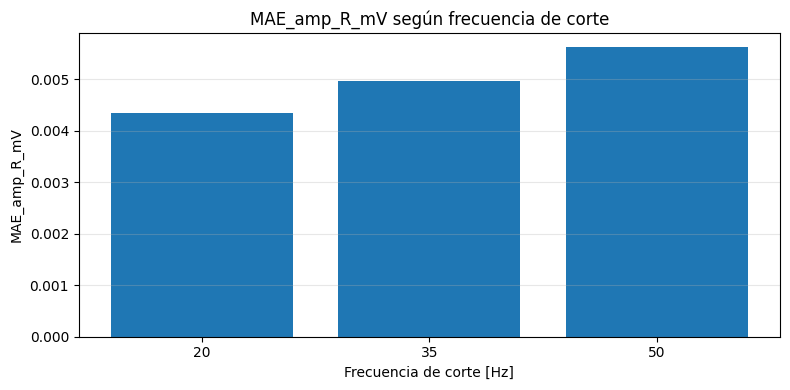

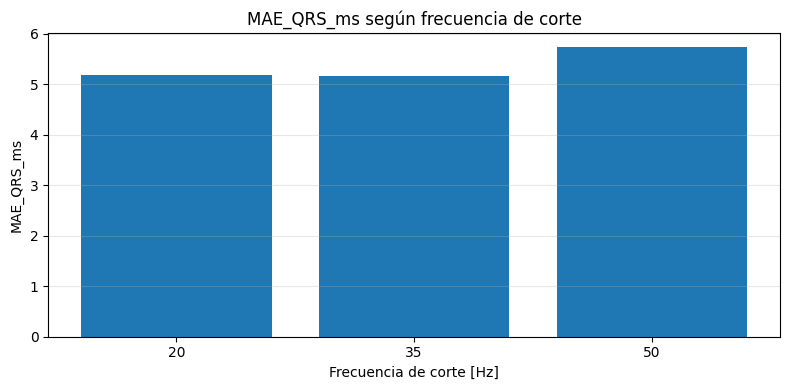

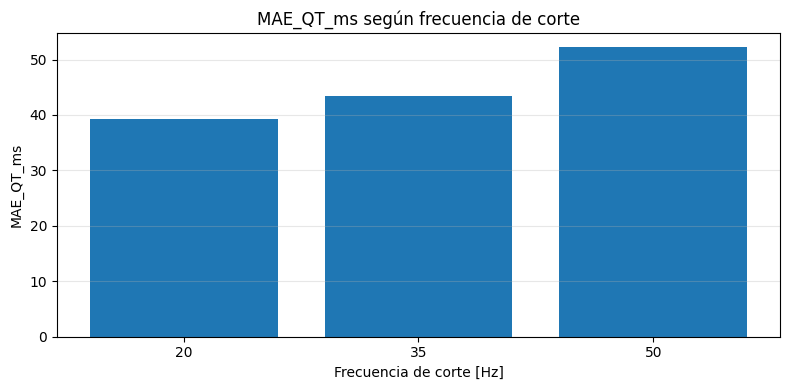

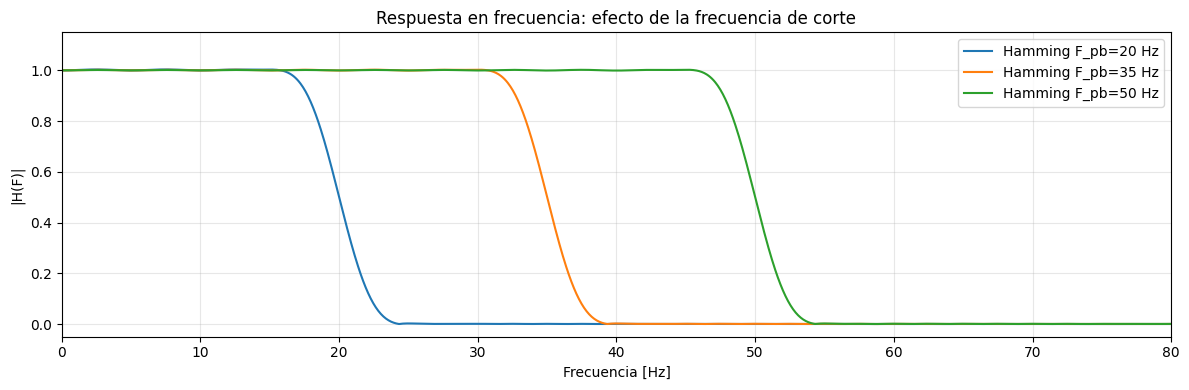

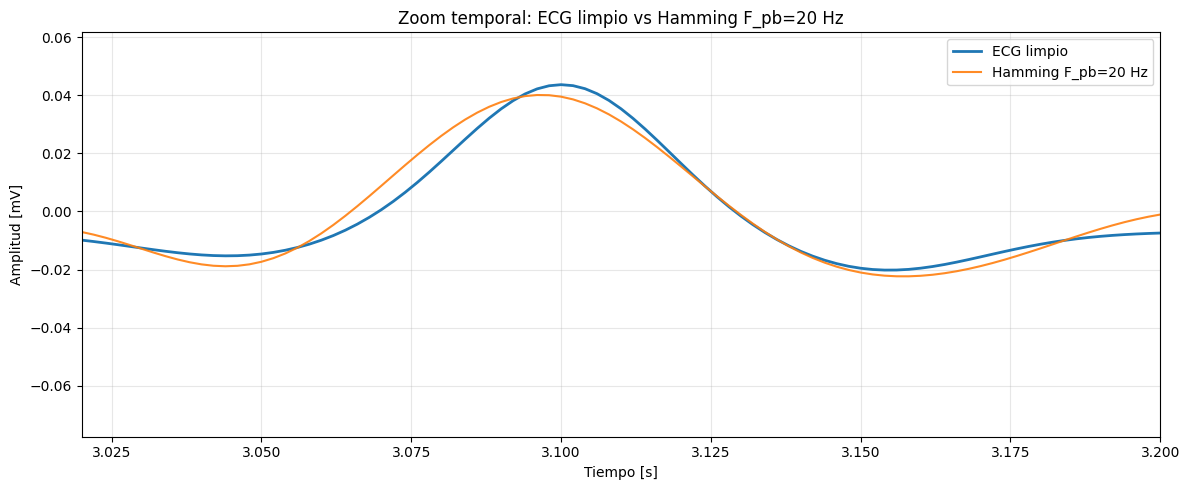

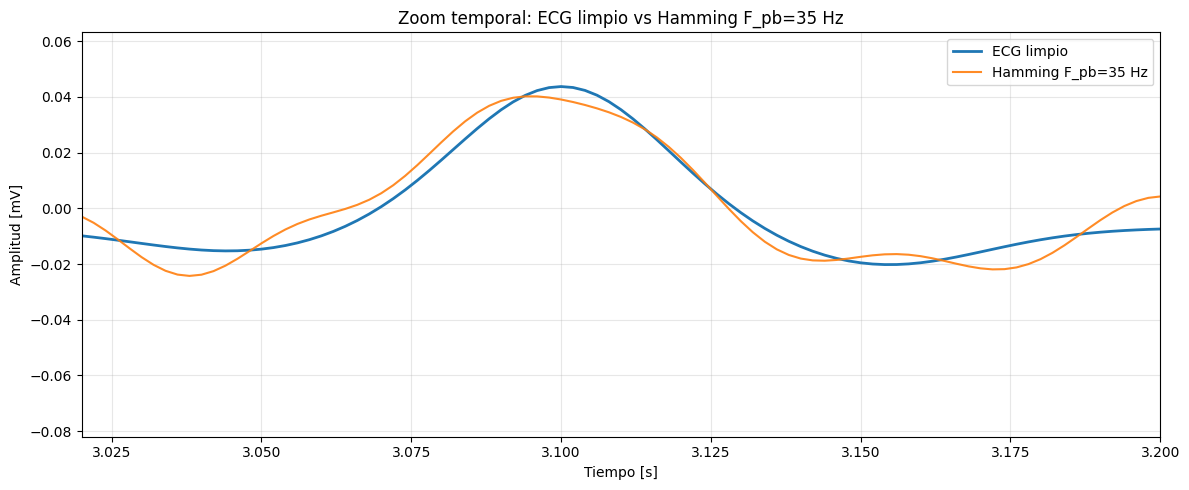

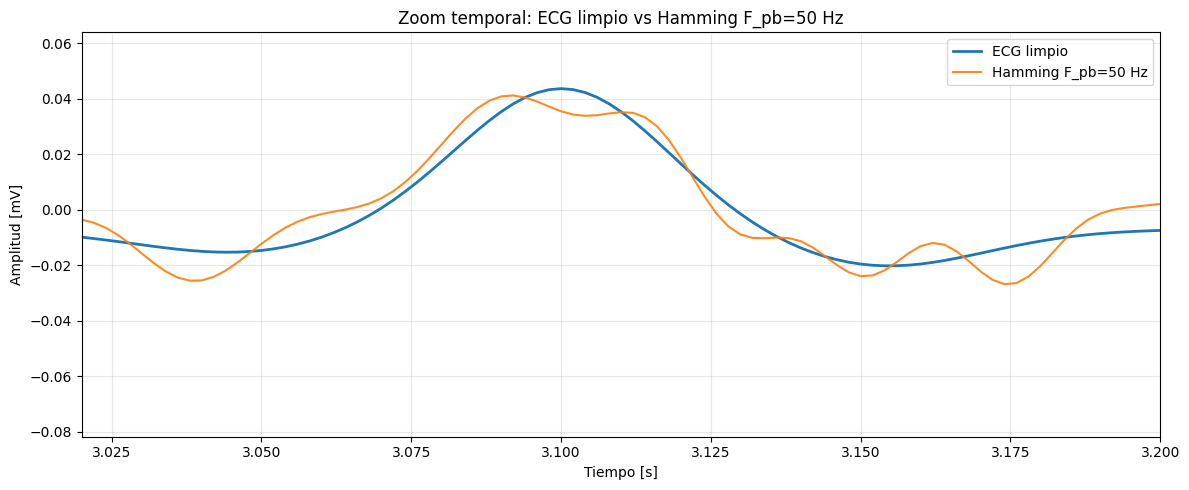

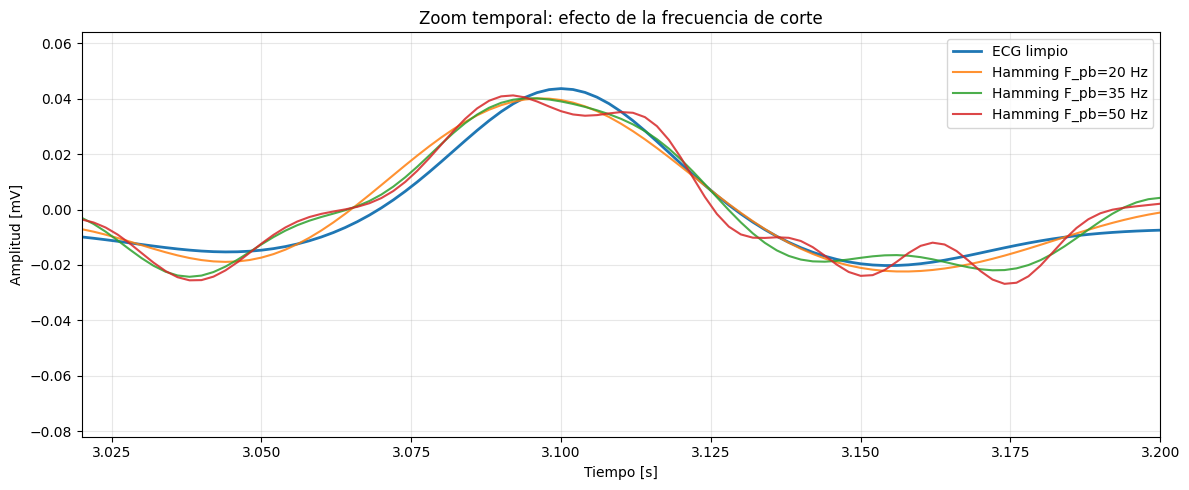

In [16]:
# ============================================================
# Experimento 3: efecto de la frecuencia de corte
# Hamming con M=201 y F_pb = 20, 35, 50 Hz
# ============================================================

fc_values = [20, 35, 50]

senales_exp_fc = {}
filtros_exp_fc = {}
resultados_exp_fc = []

for fc in fc_values:
    fc_norm = fc / fs

    h_fc = respuesta_impulsional_ideal_paso_bajo(fc_norm, M_largo)
    h_fc = h_fc * np.hamming(M_largo)
    h_fc = h_fc / np.sum(h_fc)

    senal_fc = aplicar_filtro_fir_cero_fase(ecg_preprocesado, h_fc)

    nombre = f"Hamming F_pb={fc} Hz"
    senales_exp_fc[nombre] = senal_fc
    filtros_exp_fc[nombre] = h_fc

    m = medir_senal(senal_fc, ecg_referencia, picos_ref, fs)

    resultados_exp_fc.append({
        "Filtro": nombre,
        "F_pb_Hz": fc,
        "RMSE_global": m["rmse_global"],
        "MAE_tiempo_R_ms": 1000 * np.mean(np.abs(m["error_tiempo_R"])),
        "MAE_amp_R_mV": np.mean(np.abs(m["error_amp_R"])),
        "MAE_QRS_ms": 1000 * np.mean(np.abs(m["error_qrs"])),
        "MAE_QT_ms": m["mae_qt_ms"]
    })

tabla_exp_fc = pd.DataFrame(resultados_exp_fc)
display(tabla_exp_fc)

# Score propio de este experimento
tabla_exp_fc_score = tabla_exp_fc.copy()

for col in metric_cols:
    mn = tabla_exp_fc_score[col].min()
    mx = tabla_exp_fc_score[col].max()
    if mx > mn:
        tabla_exp_fc_score[col + "_norm"] = (tabla_exp_fc_score[col] - mn) / (mx - mn)
    else:
        tabla_exp_fc_score[col + "_norm"] = 0.0

tabla_exp_fc_score["score_global"] = tabla_exp_fc_score[
    [c + "_norm" for c in metric_cols]
].mean(axis=1)

tabla_exp_fc_score = tabla_exp_fc_score.sort_values("score_global").reset_index(drop=True)

display(tabla_exp_fc_score[["Filtro", "F_pb_Hz", "score_global"]])

# Barras de métricas según F_pb
for col in metric_cols:
    plt.figure(figsize=(8,4))
    plt.bar(tabla_exp_fc["F_pb_Hz"].astype(str), tabla_exp_fc[col])
    plt.title(f"{col} según frecuencia de corte")
    plt.xlabel("Frecuencia de corte [Hz]")
    plt.ylabel(col)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Respuesta en frecuencia
plt.figure(figsize=(12,4))
for nombre, h in filtros_exp_fc.items():
    w, H = signal.freqz(h, worN=4096, fs=fs)
    plt.plot(w, np.abs(H), label=nombre)

plt.xlim(0, 80)
plt.ylim(-0.05, 1.15)
plt.title("Respuesta en frecuencia: efecto de la frecuencia de corte")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|H(F)|")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Zoom individual
for nombre, senal in senales_exp_fc.items():
    plt.figure(figsize=(12,5))
    plt.plot(t, ecg_referencia, label="ECG limpio", linewidth=2)
    plt.plot(t, senal, label=nombre, alpha=0.9)
    plt.title(f"Zoom temporal: ECG limpio vs {nombre}")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud [mV]")
    plt.xlim(3.02, 3.20)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Zoom conjunto
plt.figure(figsize=(12,5))
plt.plot(t, ecg_referencia, label="ECG limpio", linewidth=2)

for nombre, senal in senales_exp_fc.items():
    plt.plot(t, senal, label=nombre, alpha=0.85)

plt.title("Zoom temporal: efecto de la frecuencia de corte")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [mV]")
plt.xlim(3.02, 3.20)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

tabla_exp_fc.to_csv("resumen_experimento_frecuencia_corte.csv", index=False)
tabla_exp_fc_score.to_csv("resumen_score_experimento_frecuencia_corte.csv", index=False)

En este experimento se fija el filtro Hamming con $M=201$ y se modifica únicamente la frecuencia de corte $F_{\mathrm{pb}}$. Los resultados muestran lo siguiente:

- Con $F_{\mathrm{pb}}=20\,\mathrm{Hz}$, se obtiene el menor RMSE global $(0.005558)$, el menor error temporal del pico R $(1.57\,\mathrm{ms})$, el menor error de amplitud del pico R $(0.004349\,\mathrm{mV})$ y también el menor `score_global` $(0.002458)$. Esto indica que, para esta señal y este nivel de ruido, el filtrado más agresivo reduce mejor las oscilaciones residuales.

- Con $F_{\mathrm{pb}}=35\,\mathrm{Hz}$, se obtiene el mejor resultado en la anchura aproximada del QRS $(5.17\,\mathrm{ms})$, aunque sus errores globales son algo mayores que con $20\,\mathrm{Hz}$.

- Con $F_{\mathrm{pb}}=50\,\mathrm{Hz}$, el filtro deja pasar una banda frecuencial más amplia, pero también conserva más ruido residual. Por eso presenta los peores valores en todas las métricas de esta comparación.

La respuesta en frecuencia confirma este comportamiento: al disminuir $F_{\mathrm{pb}}$, el filtro elimina una mayor parte de las componentes altas; al aumentarla, conserva más contenido rápido. En el dominio temporal, $20\,\mathrm{Hz}$ produce la señal más suave, $50\,\mathrm{Hz}$ conserva más oscilaciones rápidas y $35\,\mathrm{Hz}$ actúa como una opción intermedia.

En conjunto, $F_{\mathrm{pb}}=20\,\mathrm{Hz}$ obtiene el mejor resultado global en este experimento. Sin embargo, como $35\,\mathrm{Hz}$ preserva ligeramente mejor la anchura del QRS, la elección de la frecuencia de corte debe interpretarse como un compromiso entre reducción de ruido y preservación de rasgos morfológicos concretos.

## **5.Conclusiones experimentales**

La comparación separada permite interpretar mejor el efecto de cada parámetro del filtrado. La longitud $M$ muestra el compromiso entre duración temporal del filtro y selectividad frecuencial; la comparación entre rectangular largo y Hamming, ambos con $M=201$, permite aislar el efecto de la ventana; y el análisis de la frecuencia de corte $F_{\mathrm{pb}}$ muestra cómo cambia el equilibrio entre reducción de ruido y preservación de componentes rápidas del ECG.

Los resultados obtenidos confirman la idea central del TFG: el filtrado no debe evaluarse únicamente por su capacidad para eliminar ruido en el dominio frecuencial, sino también por su efecto sobre la morfología temporal de la señal. Una mayor selectividad en frecuencia o un menor error global no implican necesariamente una mejor preservación de rasgos como la amplitud del pico R, la anchura del complejo QRS o la estimación del intervalo QT.

Por tanto, los resultados no deben interpretarse como una elección universal de un único filtro, sino como evidencia de que cada parámetro modifica la señal de una forma distinta. En este experimento, la elección del filtro debe entenderse como un compromiso entre supresión de ruido, suavidad temporal y conservación de la morfología del ECG.